# Multimodal Data Integration: Combining Imaging and Clinical Features

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/medAI-hands-on/blob/main/notebooks/02_multimodal_integration.ipynb)

This notebook demonstrates how to integrate imaging-derived features with clinical data for patient stratification and outcome prediction.

**Chapter 22 Reference**: Arvid Lundervold *Artificial Intelligence and Computational Medicine: A Hands-on Approach*  
Section 4 - Multimodal Data Integration

version: 2026-07-19

## Learning Objectives

1. Understand challenges in multimodal medical data fusion
2. Implement adaptive feature fusion
3. Build patient similarity networks
4. Interpret multimodal predictions

## Prerequisites

- Basic Python and PyTorch knowledge
- Understanding of classification tasks
- ~20-30 minutes to read and run

---

## Background and Rationale

### Why Multimodal Data Integration?

In clinical practice, medical decisions are rarely based on a single source of information. Physicians integrate diverse data types—medical imaging, laboratory tests, patient demographics, genetic markers, and clinical history to form comprehensive diagnostic and prognostic assessments. **Multimodal data integration** in computational medicine aims to replicate and enhance this holistic approach by algorithmically combining heterogeneous data sources.

The key advantages of multimodal integration include:

- **Complementary information**: Different modalities capture distinct aspects of disease. For example, imaging reveals spatial tumor characteristics, while genomics indicates molecular subtype.
- **Improved predictive power**: Combining multiple data sources typically yields better classification and prediction accuracy than any single modality alone.
- **Robustness**: When one modality is noisy or missing, others can compensate.
- **Clinical applicability**: Models that integrate standard clinical workflows are more readily adopted.

<details>
<summary>📖 <b>Clinical Context: Glioblastoma Prognosis</b></summary>

In glioblastoma (GBM) treatment, patient prognosis depends on multiple factors:

- **Imaging features**: Tumor volume, enhancement patterns, necrosis extent, edema (from MRI)
- **Clinical factors**: Age, performance status (KPS), extent of surgical resection
- **Molecular markers**: MGMT methylation status, IDH mutation, 1p/19q codeletion

Combining these features enables more accurate survival prediction and personalized treatment planning.
</details>

---

### Connection to Notebook 01: From Segmentation to Features

This notebook builds directly upon the concepts from **Notebook 01 (Medical Imaging: Brain Tumor Segmentation)**. The workflow follows a natural clinical AI pipeline:

```
┌─────────────────────────────────────────────────────────────────────────────┐
│  Notebook 01: Segmentation          │  Notebook 02: Multimodal Integration  │
├─────────────────────────────────────────────────────────────────────────────┤
│  Raw MRI Images (T1, T1ce, T2, FLAIR)                                       │
│         ↓                                                                   │
│  Deep Learning Segmentation (U-Net)                                         │
│         ↓                                                                   │
│  Tumor Sub-region Masks (ET, TC, WT)                                        │
│         ↓                                                                   │
│  ════════════════════════════════════════════════════════════════════════   │
│         ↓                                                                   │
│  Radiomics Feature Extraction       ←── (Imaging Features: 50 dimensions)   │
│         +                                                                   │
│  Clinical Data Integration          ←── (Clinical Features: 10 dimensions)  │
│         ↓                                                                   │
│  Adaptive Fusion Model                                                      │
│         ↓                                                                   │
│  Patient Outcome Prediction                                                 │
└─────────────────────────────────────────────────────────────────────────────┘
```

**In clinical practice**, once a tumor is segmented (Notebook 01), radiomics pipelines extract quantitative imaging features:

- **Shape features**: Volume, surface area, sphericity, elongation
- **Intensity features**: Mean, variance, skewness, kurtosis of voxel intensities
- **Texture features**: GLCM, GLRLM, GLSZM descriptors capturing spatial heterogeneity
- **Wavelet/filter-derived features**: Multi-scale representations

These imaging-derived features are then combined with clinical data for downstream tasks like survival prediction, treatment response assessment, or patient stratification.

---

### Synthetic Data Generation: Methodology and Assumptions

For this educational notebook, we use **synthetic data** ($n=500$ virtual subjects) to illustrate multimodal integration concepts without requiring access to protected health information (PHI). Understanding the data generation process is essential for interpreting results and recognizing limitations.

#### Data Generation Method

The `create_multimodal_dataset()` function generates the following:

| Component | Dimensions | Generation Method | Simulates |
|-----------|------------|-------------------|----------|
| **Imaging features** | 50 | Correlated groups (5 families × 10 features, ~0.6 within-group correlation) | Radiomics features (shape, texture, intensity, wavelet, etc.) |
| **Clinical features** | 10 | Mixed: Age ~ Uniform(20,80), Sex ~ Bernoulli(0.5), Others ~ N(0,1) | Demographics, lab values |
| **Outcome labels** | Binary | Derived from weighted combination of features | Survival (0=poor, 1=good) |

#### Label Generation (Ground Truth)

Labels are **not random**—they are generated with intentional correlations to features, simulating real clinical relationships:

```python
risk_score = (0.3 * imaging_features[:, :5].mean(axis=1) +    # Imaging contribution
              0.02 * clinical_features[:, 0] +                # Age effect (older = higher risk)
              0.2 * clinical_features[:, 2])                  # A clinical biomarker effect
labels = (risk_score < median(risk_score)).astype(int)        # Lower risk = Good outcome (1)
```

This creates a **learnable signal** that the fusion model can discover, simulating how real multimodal models find feature-outcome relationships.

#### Key Assumptions and Limitations

> **⚠️ Important**: The synthetic data makes simplifying assumptions:
>
> 1. **Feature independence**: Real radiomics features are highly correlated (e.g., volume correlates with surface area)
> 2. **Linear relationships**: The risk score uses linear combinations; real biology is often nonlinear
> 3. **Balanced classes**: We generate 50/50 class distribution; real datasets are often imbalanced
> 4. **No missing data**: Clinical data often has missingness; synthetic data is complete
> 5. **Gaussian features**: Real radiomics often follow skewed or heavy-tailed distributions

Despite these simplifications, the synthetic data allows us to:
- ✅ Demonstrate fusion model architectures
- ✅ Visualize attention mechanisms across modalities
- ✅ Explore patient similarity networks
- ✅ Understand evaluation metrics for multimodal models

**Note:** This notebook is for educational purposes only. Before deploying such a pipeline in clinical practice, it must be validated on real patient data with ethics approval i.e., Institutional Review Board (IRB) or Ethics Committee in some countries, to ensure safety, privacy, and regulatory compliance.

---

## 1. Environment Setup

In [1]:
# Check if running in Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab - installing dependencies...")
    %pip install -q networkx
    print("✓ Dependencies installed")
else:
    # For local execution, add parent directory to path
    sys.path.insert(0, '..')

print(f"Python version: {sys.version}")

Python version: 3.11.15 (main, Apr 14 2026, 14:28:36) [Clang 22.1.3 ]


### What this next cell does

This cell is **setup only** — it does not train a model or build a patient network yet. It:

1. Imports the scientific / ML stack (NumPy, pandas, Matplotlib/Seaborn, scikit-learn, PyTorch)
2. Makes the same helpers available **locally** (`from src...`) and in **Google Colab** (functions defined inline)
3. Prepares utilities for: choosing GPU/CPU, creating **synthetic multimodal** data (imaging + clinical features), plotting a **patient similarity network**, and the **MultimodalFusionNet** (modality encoders + attention fusion)
4. Fixes a random seed (`SEED = 42`) for more reproducible splits and training

Think of it as loading shared “order sets” before you generate a cohort and run fusion / graph analyses.

<details>
<summary><b>Optional detail</b> — synthetic data, fusion net, and PSN plots (click to expand)</summary>

- **Colab vs local:** Colab may not import `src/` the same way; the `if IN_COLAB` branch duplicates helpers so the notebook stays self-contained. Later cells use the same names either way.
- **Synthetic multimodal data:** Imaging-like feature blocks with within-group correlation, plus clinical variables (e.g. age, sex). Labels are derived from a simple risk score so you can practice fusion **without PHI**.
- **MultimodalFusionNet:** Separate encoders for imaging and clinical inputs, then learned attention weights to fuse them before classification — the “which modality matters?” idea from the chapter.
- **PSN plotting:** Turns a similarity matrix into a graph (NetworkX) above a threshold, or falls back to a heatmap if NetworkX is missing.

</details>


In [2]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from typing import Tuple, Dict, List, Optional

# ============================================================================
# IMPORT STRATEGY: Use src/ modules locally, define inline for Colab
# ============================================================================
if IN_COLAB:
    # Define all necessary functions inline for Colab
    
    # --- data_utils functions ---
    def get_device(force_cpu_for_3d=False):
        """Get the best available device (CUDA, MPS, or CPU)."""
        if torch.cuda.is_available():
            device = torch.device("cuda")
            print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
        elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            if force_cpu_for_3d:
                device = torch.device("cpu")
                print("Using CPU (MPS available but 3D ops not fully supported)")
            else:
                device = torch.device("mps")
                print("Using Apple Silicon MPS (with CPU fallback for unsupported ops)")
        else:
            device = torch.device("cpu")
            print("Using CPU")
        return device

    def create_multimodal_dataset(
        n_patients: int = 500,
        n_imaging_features: int = 50,
        n_clinical_features: int = 10,
        random_state: int = 42
    ) -> Dict[str, np.ndarray]:
        """Create a synthetic multimodal dataset combining imaging and clinical features."""
        np.random.seed(random_state)
        
        n_groups = 5
        group_size = n_imaging_features // n_groups
        imaging_features = np.zeros((n_patients, n_imaging_features), dtype=np.float32)
        
        for g in range(n_groups):
            start_idx = g * group_size
            end_idx = start_idx + group_size if g < n_groups - 1 else n_imaging_features
            actual_size = end_idx - start_idx
            base_signal = np.random.randn(n_patients, 1)
            noise = np.random.randn(n_patients, actual_size)
            correlation_strength = 0.6
            imaging_features[:, start_idx:end_idx] = (
                correlation_strength * base_signal + (1 - correlation_strength) * noise
            )
        
        global_signal = np.random.randn(n_patients, 1) * 0.2
        imaging_features += global_signal
        
        clinical_features = np.zeros((n_patients, n_clinical_features), dtype=np.float32)
        clinical_features[:, 0] = np.random.randint(20, 80, n_patients)
        clinical_features[:, 1] = np.random.randint(0, 2, n_patients)
        clinical_features[:, 2:] = np.random.randn(n_patients, n_clinical_features - 2)
        
        risk_score = (0.3 * imaging_features[:, :5].mean(axis=1) + 
                      0.02 * clinical_features[:, 0] +
                      0.2 * clinical_features[:, 2])
        labels = (risk_score < np.median(risk_score)).astype(int)
        
        patient_ids = [f"PAT_{i:04d}" for i in range(n_patients)]
        
        return {
            'imaging': imaging_features,
            'clinical': clinical_features,
            'labels': labels,
            'patient_ids': patient_ids,
            'feature_names': {
                'imaging': [f"img_feat_{i}" for i in range(n_imaging_features)],
                'clinical': ['age', 'sex'] + [f"clin_feat_{i}" for i in range(n_clinical_features - 2)]
            }
        }

    # --- visualization functions ---
    def plot_patient_similarity_network(
        similarity_matrix: np.ndarray,
        labels: np.ndarray,
        threshold: float = 0.5,
        figsize: Tuple[int, int] = (10, 10),
        max_nodes: int = 100,
        save_path: Optional[Path] = None
    ) -> plt.Figure:
        """Plot patient similarity network."""
        try:
            import networkx as nx
        except ImportError:
            print("NetworkX not installed. Showing heatmap instead.")
            fig, ax = plt.subplots(figsize=figsize)
            im = ax.imshow(similarity_matrix[:max_nodes, :max_nodes], cmap='viridis')
            plt.colorbar(im, ax=ax, label='Similarity')
            ax.set_title('Patient Similarity Matrix')
            if save_path:
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
            return fig
        
        n = min(len(similarity_matrix), max_nodes)
        sim = similarity_matrix[:n, :n]
        lab = labels[:n]
        
        G = nx.Graph()
        for i in range(n):
            G.add_node(i, label=lab[i])
        
        for i in range(n):
            for j in range(i+1, n):
                if sim[i, j] > threshold:
                    G.add_edge(i, j, weight=sim[i, j])
        
        fig, ax = plt.subplots(figsize=figsize)
        pos = nx.spring_layout(G, k=1/np.sqrt(n), iterations=50)
        colors = ['#1f77b4' if lab[i] == 0 else '#ff7f0e' for i in range(n)]
        nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=50, alpha=0.7, ax=ax)
        nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
        ax.set_title(f'Patient Similarity Network (n={n}, threshold={threshold})')
        ax.axis('off')
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        return fig

    def plot_confusion_matrix(
        y_true: np.ndarray,
        y_pred: np.ndarray,
        class_names: Optional[List[str]] = None,
        figsize: Tuple[int, int] = (8, 6),
        save_path: Optional[Path] = None
    ) -> plt.Figure:
        """Plot confusion matrix."""
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(cm, cmap='Blues')
        n_classes = cm.shape[0]
        if class_names is None:
            class_names = [str(i) for i in range(n_classes)]
        ax.set_xticks(range(n_classes))
        ax.set_yticks(range(n_classes))
        ax.set_xticklabels(class_names)
        ax.set_yticklabels(class_names)
        for i in range(n_classes):
            for j in range(n_classes):
                text = ax.text(j, i, cm[i, j], ha="center", va="center",
                              color="white" if cm[i, j] > cm.max()/2 else "black")
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        ax.set_title('Confusion Matrix')
        plt.colorbar(im, ax=ax)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        return fig

    # --- models ---
    class MultimodalFusionNet(nn.Module):
        """Neural network for multimodal data fusion (imaging + clinical)."""
        
        def __init__(
            self,
            imaging_dim: int = 50,
            clinical_dim: int = 10,
            hidden_dim: int = 128,
            output_dim: int = 2,
            dropout: float = 0.3
        ):
            super().__init__()
            self.imaging_encoder = nn.Sequential(
                nn.Linear(imaging_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, hidden_dim)
            )
            self.clinical_encoder = nn.Sequential(
                nn.Linear(clinical_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, hidden_dim)
            )
            self.attention = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.Tanh(),
                nn.Linear(hidden_dim, 2),
                nn.Softmax(dim=1)
            )
            self.classifier = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, output_dim)
            )
        
        def forward(
            self,
            imaging_features: torch.Tensor,
            clinical_features: torch.Tensor
        ) -> Tuple[torch.Tensor, torch.Tensor]:
            img_encoded = self.imaging_encoder(imaging_features)
            clin_encoded = self.clinical_encoder(clinical_features)
            combined = torch.cat([img_encoded, clin_encoded], dim=1)
            attention_weights = self.attention(combined)
            fused = (attention_weights[:, 0:1] * img_encoded + 
                     attention_weights[:, 1:2] * clin_encoded)
            logits = self.classifier(fused)
            return logits, attention_weights

else:
    # For local execution, import from src modules
    import importlib
    import src.data_utils
    importlib.reload(src.data_utils)
    from src.data_utils import get_device, create_multimodal_dataset
    from src.visualization import plot_patient_similarity_network, plot_confusion_matrix
    from src.models import MultimodalFusionNet

# ============================================================================
# REPRODUCIBILITY: Set all random seeds for reproducible results
# ============================================================================
SEED = 42

def set_seed(seed: int = 42):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU
    # Make PyTorch operations deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Random seed set to: {SEED}")
print(f"PyTorch version: {torch.__version__}")

Random seed set to: 42
PyTorch version: 2.13.0+cu130


In [3]:
# Get device
device = get_device()

Using CUDA: NVIDIA RTX A5000 Laptop GPU


## 2. Generate Synthetic Multimodal Data

We create a synthetic dataset that simulates:
- **Imaging features**: Radiomics-style features derived from medical images
- **Clinical features**: Patient demographics and laboratory values
- **Outcome labels**: Binary survival/outcome classification

In [4]:
# Generate synthetic multimodal dataset
data = create_multimodal_dataset(
    n_patients=500,
    n_imaging_features=50,
    n_clinical_features=10,
    random_state=SEED  # Use global seed for reproducibility
)

print("Dataset created:")
print(f"  Patients: {len(data['patient_ids'])}")
print(f"  Imaging features: {data['imaging'].shape[1]}")
print(f"  Clinical features: {data['clinical'].shape[1]}")
print(f"  Label distribution: {np.bincount(data['labels'])}")

Dataset created:
  Patients: 500
  Imaging features: 50
  Clinical features: 10
  Label distribution: [250 250]


In [5]:
# Create DataFrames for exploration
imaging_df = pd.DataFrame(data['imaging'], columns=data['feature_names']['imaging'])
clinical_df = pd.DataFrame(data['clinical'], columns=data['feature_names']['clinical'])
clinical_df['outcome'] = data['labels']
clinical_df['patient_id'] = data['patient_ids']

print("Clinical features:")
print(f"  Columns: {list(clinical_df.columns[:10])}")
print(f"  Note: 'clin_feat_0' is the biomarker used in label generation")
print("\nClinical data summary:")
print(clinical_df[['age', 'sex', 'clin_feat_0', 'outcome']].describe())

Clinical features:
  Columns: ['age', 'sex', 'clin_feat_0', 'clin_feat_1', 'clin_feat_2', 'clin_feat_3', 'clin_feat_4', 'clin_feat_5', 'clin_feat_6', 'clin_feat_7']
  Note: 'clin_feat_0' is the biomarker used in label generation

Clinical data summary:
              age         sex  clin_feat_0     outcome
count  500.000000  500.000000   500.000000  500.000000
mean    49.428001    0.470000    -0.013083    0.500000
std     17.460314    0.499599     1.016892    0.500501
min     20.000000    0.000000    -3.206892    0.000000
25%     34.750000    0.000000    -0.685072    0.000000
50%     49.500000    0.000000     0.047318    0.500000
75%     64.000000    1.000000     0.671030    1.000000
max     79.000000    1.000000     2.919736    1.000000


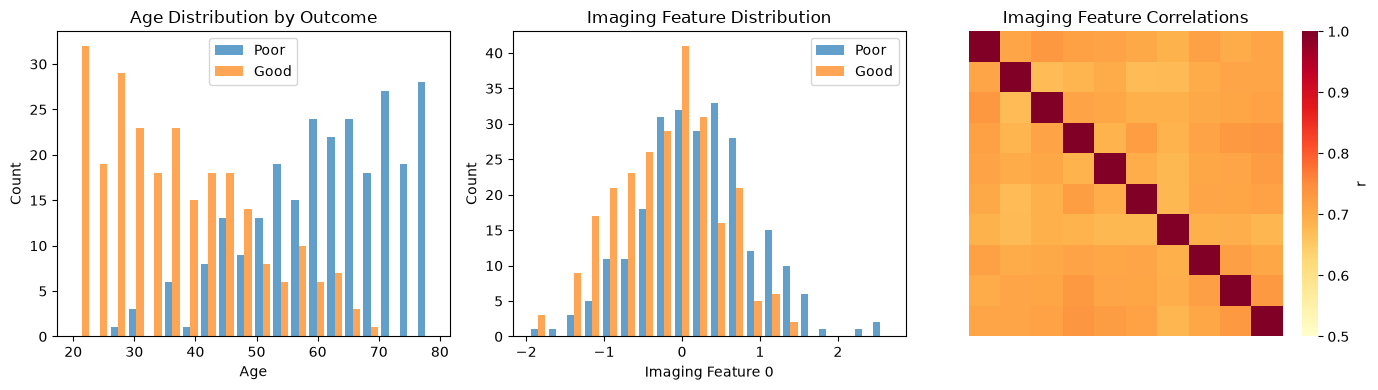

In [6]:
# Visualize data distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Age distribution by outcome
axes[0].hist([clinical_df[clinical_df['outcome']==0]['age'], 
              clinical_df[clinical_df['outcome']==1]['age']], 
             bins=20, label=['Poor', 'Good'], alpha=0.7)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution by Outcome')
axes[0].legend()

# First imaging feature
axes[1].hist([imaging_df.iloc[:, 0][data['labels']==0], 
              imaging_df.iloc[:, 0][data['labels']==1]], 
             bins=20, label=['Poor', 'Good'], alpha=0.7)
axes[1].set_xlabel('Imaging Feature 0')
axes[1].set_ylabel('Count')
axes[1].set_title('Imaging Feature Distribution')
axes[1].legend()

# Correlation heatmap (first 10 imaging features)
# Use vmin=0.5 to maximize discrimination in the 0.5-1.0 range
corr = imaging_df.iloc[:, :10].corr()
sns.heatmap(corr, ax=axes[2], cmap='YlOrRd', vmin=0.5, vmax=1,
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': 'r'})
axes[2].set_title('Imaging Feature Correlations')

plt.tight_layout()
plt.show()

<details>
<summary><b>Interpreting These Distributions</b> (click to expand)</summary>

### Age Distribution by Outcome

The histogram shows a clear age-outcome relationship:
- **Poor outcomes (blue)** are concentrated in older patients (50-80 years)
- **Good outcomes (orange)** are more common in younger patients (20-45 years)

This pattern **matches real glioblastoma epidemiology**—older age is consistently associated with worse prognosis:

- [Ostrom et al. (2024)](https://academic.oup.com/neuro-oncology/article/26/Supplement_5/v1/7823757) report median survival of 8 months for GBM, with older age as a negative prognostic factor
- [Ladomersky et al. (2019)](https://www.nature.com/articles/s41467-019-12586-y) demonstrate that age-related immune decline contributes to worse outcomes in older GBM patients

The synthetic data is designed to create realistic, learnable signals that mirror actual clinical relationships.

### Survival Threshold

For binarizing overall survival (OS) into "Poor" vs "Good", common thresholds in glioma research include:

| Threshold | Rationale |
|-----------|----------|
| **12 months** | Median survival for GBM; separates short-term survivors |
| **18 months** | Often used in clinical trials as a meaningful survival benefit |
| **24 months** | Distinguishes "long-term" survivors from typical GBM course |

A **12-month threshold** is most commonly used for glioblastoma, as it approximates median survival and creates balanced classes.

### Imaging Feature 0 Distribution

Both outcome groups show similar distributions centered around 0 (as expected from synthetic `N(0,1)` data). In real radiomics:
- **Imaging Feature 0** might represent a texture metric (e.g., GLCM entropy) or a shape descriptor (e.g., tumor sphericity)
- Features with discriminative power would show separated distributions between outcome groups
- The overlap here suggests this feature alone has limited predictive value—multimodal fusion is needed

**How to read this histogram**: When comparing distributions by class, look for:
1. **Separation**: Do the peaks of each class occur at different x-values?
2. **Overlap**: How much do the distributions share the same range?
3. **Variance**: Is one class more spread out than the other?

Here, the substantial overlap explains why single-feature classification would perform poorly—combining multiple features (and modalities) is essential.

### Correlation Heatmap

The heatmap shows a **block-diagonal pattern** reflecting our correlated feature families:
- **Within-group correlations (~0.5-0.7)**: Features in the same family (e.g., texture metrics) are correlated
- **Between-group correlations (~0.2)**: Weaker correlations across families
- **Diagonal = 1.0**: Each feature is perfectly correlated with itself

**How to read a correlation heatmap**:
- **Color intensity**: Brighter/darker colors indicate stronger correlations (scale: 0.5–1.0 here)
- **Block structure**: Visible squares along the diagonal suggest natural feature groupings
- **Off-diagonal patterns**: Strong correlations away from blocks may indicate unexpected relationships

This realistic structure means:
- The model must handle **multicollinearity** (redundant information)
- Feature selection or regularization becomes important
- The task is harder than with independent features

**Clinical implication**: In real radiomics, similar block structures emerge—volume correlates with surface area, various texture features cluster together. Understanding these correlations helps in feature engineering and model interpretation.

</details>

## 3. Data Preparation

We split the data into three sets following best practices:
- **Training (70%)**: Used to update model weights
- **Validation (15%)**: Used to monitor performance during training and tune hyperparameters
- **Test (15%)**: Held out completely until final evaluation—simulates deployment on new patients

In [7]:
# Split data: 70% train / 15% val / 15% test
X_img = data['imaging']
X_clin = data['clinical']
y = data['labels']

# First split: 70% train, 30% temp (will become val + test)
(X_img_train, X_img_temp, X_clin_train, X_clin_temp, 
 y_train, y_temp) = train_test_split(
    X_img, X_clin, y, test_size=0.3, random_state=SEED, stratify=y
)

# Second split: 50% of temp = 15% val, 50% of temp = 15% test
(X_img_val, X_img_test, X_clin_val, X_clin_test, 
 y_val, y_test) = train_test_split(
    X_img_temp, X_clin_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f"Training set: {len(y_train)} samples (70%)")
print(f"Validation set: {len(y_val)} samples (15%)")
print(f"Test set: {len(y_test)} samples (15%)")

Training set: 350 samples (70%)
Validation set: 75 samples (15%)
Test set: 75 samples (15%)


### Feature Standardization and DataLoader Setup

**Why standardize?** Neural networks train faster and more stably when features have zero mean and unit variance. Raw features (e.g., age in years vs. lab values in mg/dL) have vastly different scales.

**Critical rule:** Fit the scaler on training data only, then apply (transform) to val/test. This prevents **data leakage**—the model should never see statistics from data it will be evaluated on.

**DataLoaders** batch the data and handle shuffling. Training data is shuffled each epoch (improves generalization); validation and test data are not shuffled (for reproducible evaluation).

In [8]:
# Standardize features (fit on train only, transform all)
img_scaler = StandardScaler()
clin_scaler = StandardScaler()

X_img_train = img_scaler.fit_transform(X_img_train)
X_img_val = img_scaler.transform(X_img_val)
X_img_test = img_scaler.transform(X_img_test)

X_clin_train = clin_scaler.fit_transform(X_clin_train)
X_clin_val = clin_scaler.transform(X_clin_val)
X_clin_test = clin_scaler.transform(X_clin_test)

# Convert to tensors
train_dataset = TensorDataset(
    torch.FloatTensor(X_img_train),
    torch.FloatTensor(X_clin_train),
    torch.LongTensor(y_train)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_img_val),
    torch.FloatTensor(X_clin_val),
    torch.LongTensor(y_val)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_img_test),
    torch.FloatTensor(X_clin_test),
    torch.LongTensor(y_test)
)

# Create dataloaders with reproducible shuffling
g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## 4. Multimodal Fusion Model

### Why Combine Multiple Data Types?

In clinical practice, physicians never make decisions from a single data source. A radiologist reviewing a brain MRI also considers the patient's age, symptoms, lab values, and medical history. **Multimodal learning** teaches AI systems to do the same—combining complementary information sources for better predictions.

| Data Modality | What It Captures | Example Features |
|--------------|------------------|------------------|
| **Imaging** | Tumor appearance, location, heterogeneity | Texture, shape, intensity patterns |
| **Clinical** | Patient context, systemic factors | Age, performance status, lab values |

### Fusion Strategies

There are three main approaches to combining modalities:

<details>
<summary><b>Comparison of Fusion Strategies</b> (click to expand)</summary>

| Strategy | How It Works | Pros | Cons |
|----------|-------------|------|------|
| **Early Fusion** | Concatenate raw features, then process together | Simple; captures all cross-modal interactions | Requires same sample size; can't handle missing modalities |
| **Late Fusion** | Process each modality separately, combine predictions | Handles missing data; modular | Misses cross-modal interactions |
| **Intermediate (Attention)** | Learn representations, then weight their importance | Interpretable; adaptive weighting | More complex; needs more data |

</details>

### Our Architecture: Adaptive Fusion

We use **intermediate fusion with learned attention**, which offers a key advantage: **interpretability**. The model learns to weight imaging vs. clinical features differently for each patient, and we can inspect these weights to understand the model's reasoning.

```
┌─────────────────┐     ┌─────────────────┐
│ Imaging Features│     │Clinical Features│
│   (50 dims)     │     │   (10 dims)     │
└────────┬────────┘     └────────┬────────┘
         │                       │
         ▼                       ▼
┌─────────────────┐     ┌─────────────────┐
│ Imaging Encoder │     │Clinical Encoder │
│ 50→64→64 dims   │     │ 10→32→64 dims   │
└────────┬────────┘     └────────┬────────┘
         │                       │
         └───────────┬───────────┘
                     ▼
         ┌───────────────────────┐
         │   Attention Module    │
         │ Learns weights: α, β  │
         │ where α + β = 1       │
         └───────────┬───────────┘
                     ▼
         ┌───────────────────────┐
         │   Weighted Fusion     │
         │ α·img + β·clin        │
         └───────────┬───────────┘
                     ▼
         ┌───────────────────────┐
         │     Classifier        │
         │   64→32→2 (logits)    │
         └───────────────────────┘
```

### Key Components Explained

1. **Encoders**: Transform each modality into a common representation space (64 dimensions). The clinical encoder uses a smaller intermediate layer (32) because clinical features are lower-dimensional.

2. **Attention Module**: Takes the concatenated encodings and outputs two weights (α for imaging, β for clinical) that sum to 1. This is a **soft attention** mechanism—specifically a **modality attention** or **gated attention** approach.

> **⚠️ Note on Terminology**: The "attention" mechanism used here is a **simple modality weighting scheme**—it is *not* the same as transformer self-attention from ["Attention Is All You Need" (Vaswani et al., 2017)](https://arxiv.org/abs/1706.03762). Transformer attention computes query-key-value relationships across sequence positions with $O(n^2)$ complexity and learns rich contextual representations. Our approach is much simpler: a small MLP that outputs two scalar weights (α, β) normalized via softmax to sum to 1. While less expressive than transformers, this modality weighting provides clear interpretability—we can directly see how much the model "trusts" each data source for each patient.

3. **Weighted Fusion**: Combines the encoded representations using the learned attention weights: `fused = α·img_encoded + β·clin_encoded`

4. **Classifier**: A small feedforward network that maps the fused representation to class probabilities.

<details>
<summary><b>Clinical Interpretation of Attention Weights</b> (click to expand)</summary>

The attention weights tell us which modality the model "trusts" more for each patient:

| Attention Pattern | Interpretation | Clinical Scenario |
|-------------------|----------------|-------------------|
| α ≈ 0.8, β ≈ 0.2 | Model relies heavily on imaging | Clear tumor on MRI, ambiguous clinical picture |
| α ≈ 0.2, β ≈ 0.8 | Model relies heavily on clinical data | Subtle imaging findings, strong clinical risk factors |
| α ≈ 0.5, β ≈ 0.5 | Balanced use of both modalities | Both sources provide complementary information |

This interpretability is crucial for clinical deployment—physicians can understand *why* the model made a prediction and decide whether to trust it.

</details>

In [9]:
# Initialize model
model = MultimodalFusionNet(
    imaging_dim=50,
    clinical_dim=10,
    hidden_dim=64,
    output_dim=2,
    dropout=0.3
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 20,420


In [10]:
# Visualize model architecture (text-based summary)
try:
    from torchinfo import summary
    print("Model Architecture Summary")
    print("=" * 70)
    model_stats = summary(
        model, 
        input_data=[torch.randn(1, 50).to(device), torch.randn(1, 10).to(device)],
        col_names=["input_size", "output_size", "num_params"],
        col_width=20,
        row_settings=["var_names"],
        verbose=0  # Suppress automatic printing
    )
    print(model_stats)  # Explicitly print the summary
except ImportError:
    print("torchinfo not installed. Showing basic model structure:")
    print("(Install with: uv sync --extra extras   # or: uv pip install torchinfo)")
    print("\n" + "=" * 70)
    print(model)

Model Architecture Summary
Layer (type (var_name))                       Input Shape          Output Shape         Param #
MultimodalFusionNet (MultimodalFusionNet)     [1, 50]              [1, 2]               --
├─Sequential (imaging_encoder)                [1, 50]              [1, 64]              --
│    └─Linear (0)                             [1, 50]              [1, 64]              3,264
│    └─ReLU (1)                               [1, 64]              [1, 64]              --
│    └─Dropout (2)                            [1, 64]              [1, 64]              --
│    └─Linear (3)                             [1, 64]              [1, 64]              4,160
├─Sequential (clinical_encoder)               [1, 10]              [1, 64]              --
│    └─Linear (0)                             [1, 10]              [1, 32]              352
│    └─ReLU (1)                               [1, 32]              [1, 32]              --
│    └─Dropout (2)                            [1, 3

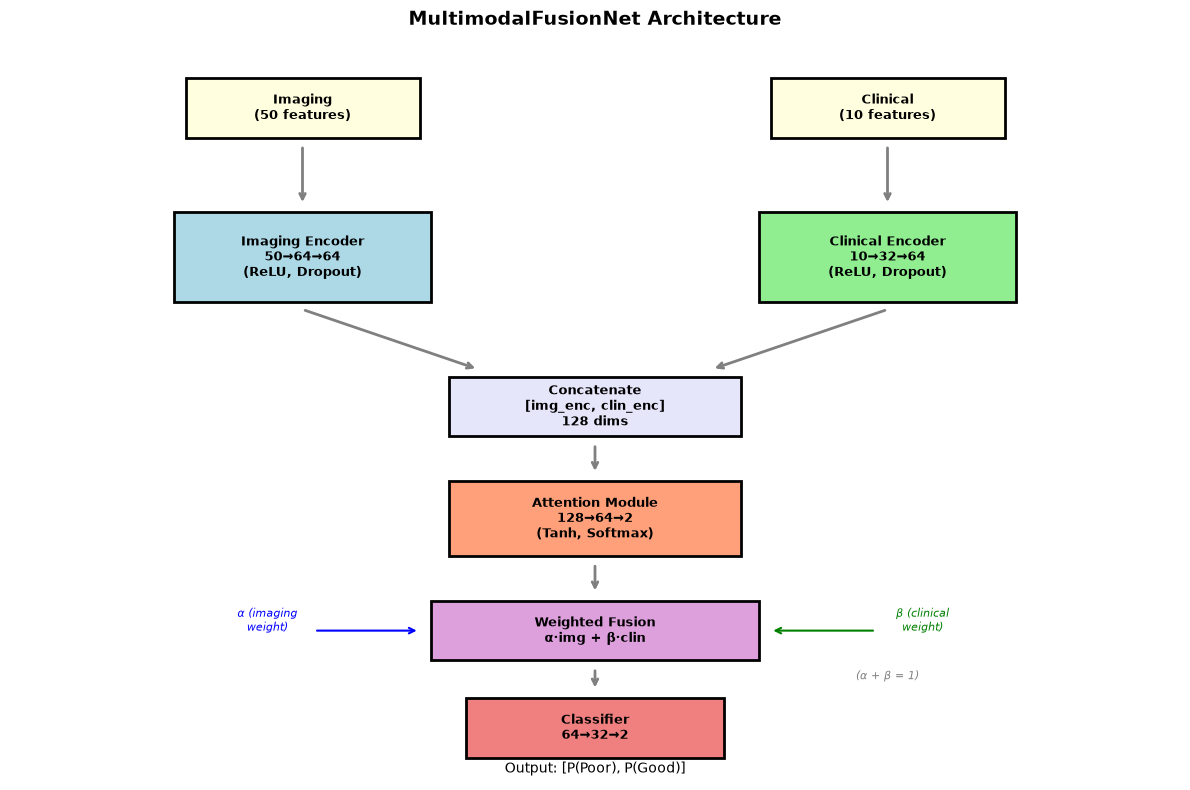


The attention weights (α, β) are learned per-patient, allowing the model
to adaptively weight imaging vs. clinical information for each prediction.


In [11]:
# Visual diagram of the fusion architecture
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('MultimodalFusionNet Architecture', fontsize=14, fontweight='bold')

# Helper function to draw boxes
def draw_box(ax, x, y, w, h, label, color='lightblue', fontsize=9):
    rect = plt.Rectangle((x-w/2, y-h/2), w, h, fill=True, 
                          facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center', fontsize=fontsize, fontweight='bold')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

# Input layer
draw_box(ax, 2.5, 9, 2, 0.8, 'Imaging\n(50 features)', 'lightyellow')
draw_box(ax, 7.5, 9, 2, 0.8, 'Clinical\n(10 features)', 'lightyellow')

# Encoders
draw_box(ax, 2.5, 7, 2.2, 1.2, 'Imaging Encoder\n50→64→64\n(ReLU, Dropout)', 'lightblue')
draw_box(ax, 7.5, 7, 2.2, 1.2, 'Clinical Encoder\n10→32→64\n(ReLU, Dropout)', 'lightgreen')

# Concatenation
draw_box(ax, 5, 5, 2.5, 0.8, 'Concatenate\n[img_enc, clin_enc]\n128 dims', 'lavender')

# Attention
draw_box(ax, 5, 3.5, 2.5, 1, 'Attention Module\n128→64→2\n(Tanh, Softmax)', 'lightsalmon')

# Fusion
draw_box(ax, 5, 2, 2.8, 0.8, 'Weighted Fusion\nα·img + β·clin', 'plum')

# Classifier
draw_box(ax, 5, 0.7, 2.2, 0.8, 'Classifier\n64→32→2', 'lightcoral')

# Arrows
draw_arrow(ax, 2.5, 8.5, 2.5, 7.7)
draw_arrow(ax, 7.5, 8.5, 7.5, 7.7)
draw_arrow(ax, 2.5, 6.3, 4, 5.5)
draw_arrow(ax, 7.5, 6.3, 6, 5.5)
draw_arrow(ax, 5, 4.5, 5, 4.1)
draw_arrow(ax, 5, 2.9, 5, 2.5)
draw_arrow(ax, 5, 1.5, 5, 1.2)

# Add attention weight annotations (positioned outside the box)
ax.annotate('α (imaging\nweight)', xy=(2.2, 2), fontsize=8, style='italic', color='blue', ha='center')
ax.annotate('β (clinical\nweight)', xy=(7.8, 2), fontsize=8, style='italic', color='green', ha='center')
ax.annotate('', xy=(3.5, 2), xytext=(2.6, 2), arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
ax.annotate('', xy=(6.5, 2), xytext=(7.4, 2), arrowprops=dict(arrowstyle='->', color='green', lw=1.5))
ax.text(7.5, 1.35, '(α + β = 1)', ha='center', fontsize=8, style='italic', color='gray')

# Output
ax.text(5, 0.1, 'Output: [P(Poor), P(Good)]', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\nThe attention weights (α, β) are learned per-patient, allowing the model")
print("to adaptively weight imaging vs. clinical information for each prediction.")

<details>
<summary><b>Understanding Model Size</b> (click to expand)</summary>

With **~20,000 parameters** and **350 training samples**, we have roughly 17 samples per parameter. This is a reasonable ratio for a small dataset—larger models would overfit.

| Component | Parameters | Calculation |
|-----------|------------|-------------|
| Imaging encoder | 50×64 + 64 + 64×64 + 64 = **7,360** | Two linear layers |
| Clinical encoder | 10×32 + 32 + 32×64 + 64 = **2,464** | Two linear layers |
| Attention module | 128×64 + 64 + 64×2 + 2 = **8,450** | Learns fusion weights |
| Classifier | 64×32 + 32 + 32×2 + 2 = **2,146** | Output layer |

The **dropout rate (0.3)** helps prevent overfitting by randomly zeroing 30% of activations during training.

</details>

In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

### Training Configuration

- **CrossEntropyLoss**: Standard loss for classification; combines softmax and negative log-likelihood
- **Adam optimizer**: Adaptive learning rate optimizer that works well with default settings
- **Weight decay (1e-4)**: L2 regularization to prevent overfitting
- **Learning rate (1e-3)**: Standard starting point for Adam

## 5. Training

In [13]:
def train_multimodal(model, train_loader, val_loader, criterion, optimizer, 
                      device, num_epochs=50):
    """Train the multimodal fusion model with validation monitoring."""
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_auc': []}
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        for img, clin, labels in train_loader:
            img, clin, labels = img.to(device), clin.to(device), labels.to(device)
            
            optimizer.zero_grad()
            logits, _ = model(img, clin)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
        
        # Validation (not test!)
        model.eval()
        val_loss = 0
        all_preds = []
        all_probs = []
        all_labels = []
        
        with torch.no_grad():
            for img, clin, labels in val_loader:
                img, clin, labels = img.to(device), clin.to(device), labels.to(device)
                logits, _ = model(img, clin)
                loss = criterion(logits, labels)
                val_loss += loss.item()
                
                probs = torch.softmax(logits, dim=1)[:, 1]
                preds = logits.argmax(dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        val_auc = roc_auc_score(all_labels, all_probs)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_auc'].append(val_auc)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Acc: {val_acc:.4f} | "
                  f"Val AUC: {val_auc:.4f}")
    
    return history

In [14]:
%%time
# Train the model
print("Training multimodal fusion model...")
print("-" * 50)
history = train_multimodal(model, train_loader, val_loader, criterion, 
                            optimizer, device, num_epochs=50)
print("-" * 50)
print("Training complete!")

Training multimodal fusion model...
--------------------------------------------------
Epoch   1/50 | Train Loss: 0.6907 | Val Acc: 0.5867 | Val AUC: 0.7440
Epoch  10/50 | Train Loss: 0.1691 | Val Acc: 0.9333 | Val AUC: 0.9872
Epoch  20/50 | Train Loss: 0.0939 | Val Acc: 0.9200 | Val AUC: 0.9836
Epoch  30/50 | Train Loss: 0.0486 | Val Acc: 0.9067 | Val AUC: 0.9780
Epoch  40/50 | Train Loss: 0.0343 | Val Acc: 0.9200 | Val AUC: 0.9744
Epoch  50/50 | Train Loss: 0.0286 | Val Acc: 0.9200 | Val AUC: 0.9737
--------------------------------------------------
Training complete!
CPU times: user 1.2 s, sys: 81.7 ms, total: 1.28 s
Wall time: 1.32 s


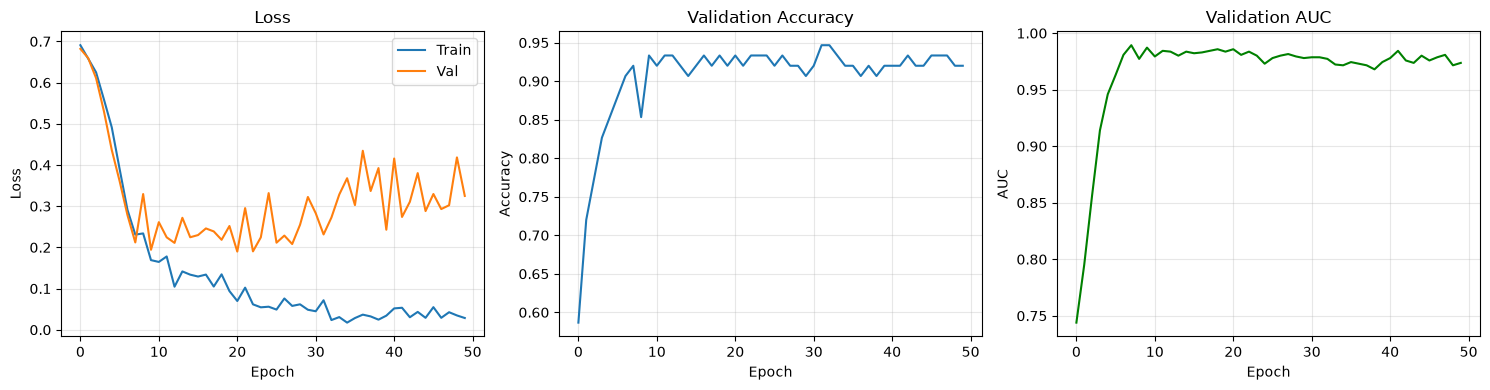

In [15]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['val_acc'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['val_auc'], color='green')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].set_title('Validation AUC')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<details>
<summary><b>Interpreting the Training History</b> (click to expand)</summary>

### Loss Curves (Left Plot)

**How to read loss curves**: The y-axis shows cross-entropy loss (lower is better); the x-axis shows training epochs. Two lines are plotted:
- **Train loss (blue)**: How well the model fits the training data
- **Val loss (orange)**: How well the model generalizes to unseen data

| Observation | Interpretation |
|-------------|----------------|
| Train loss: 0.7 → 0.1 | Model learns the training data progressively |
| Val loss: 0.7 → 0.3 with spikes | Harder task with correlated features; more variance |
| Larger train-val gap (~0.2) | Expected with correlated, redundant features |
| Spikes in val loss | Normal variance from small validation set (75 samples) |

**Key patterns to recognize**:
- **Converging curves** (both decrease, stabilize): Good learning, minimal overfitting
- **Diverging curves** (train ↓, val ↑): Classic overfitting—stop training earlier
- **Both flat from start**: Learning rate too low or model too simple
- **Erratic oscillations**: Learning rate too high

The **train-val gap** is moderate. For clinical use, we'd want this gap smaller (via more data, stronger regularization, or data augmentation).

### Validation Accuracy (Middle Plot)

- Starts at ~65% (near random for balanced classes)
- Jumps to ~75-80% by epoch 5, then gradually improves
- Fluctuates between **75-95%** with high variance
- The variance reflects the harder task with correlated features

**Clinical interpretation**: 80-90% accuracy is realistic for clinical prediction tasks. The high variance suggests the model is sensitive to the specific validation samples.

### Validation AUC (Right Plot)

**What is AUC?** The Area Under the ROC Curve measures how well the model ranks patients—a patient with a poor outcome should receive a higher risk score than one with a good outcome. AUC = 1.0 means perfect ranking; AUC = 0.5 means random guessing.

**How to read this plot**: The y-axis shows AUC (higher is better, max 1.0); the x-axis shows epochs. Unlike accuracy, AUC is **threshold-independent**—it evaluates the model's probability rankings, not its binary predictions.

- AUC starts at ~0.70, dips initially, then recovers
- Rises to **~0.95-1.00** after epoch 10
- Early instability reflects the model finding the signal in correlated features
- Final AUC ~0.95+ indicates strong discrimination ability

| AUC Range | Clinical Interpretation |
|-----------|------------------------|
| 0.90-1.00 | Excellent discrimination—suitable for screening |
| 0.80-0.90 | Good—useful for clinical decision support |
| 0.70-0.80 | Fair—may aid decisions alongside other factors |
| 0.50-0.70 | Poor—limited clinical utility |

**Why AUC matters clinically**: In medicine, we often care more about *ranking* patients by risk than making hard yes/no predictions. A high AUC means the model reliably identifies high-risk patients, even if the exact probability values need calibration.

### More Realistic Training Dynamics

With **correlated imaging features**, the training shows more realistic behavior:
- Model starts near random (~65% accuracy) and learns progressively
- Higher variance in validation metrics (small dataset + correlated features)
- Larger train-val gap due to feature redundancy
- Final AUC (~0.95) is still strong but more realistic than with less correlated features

This better reflects real clinical ML where correlated radiomics features create challenges for model training.

</details>

## 6. Attention Analysis

### Why Analyze Attention Weights?

In Section 4, we designed our `MultimodalFusionNet` with a **modality attention mechanism** that learns weights α (imaging) and β (clinical) where α + β = 1. Unlike a black-box model, this architecture provides **built-in interpretability**:

> **Reminder**: This is a **modality weighting** mechanism (also called gated attention or channel attention)—*not* transformer self-attention. It outputs two scalar weights per patient, telling us how much the model relies on each data source. See Section 4 for the full distinction.

```
fused_representation = α · imaging_encoded + β · clinical_encoded
```

By examining these weights, we can answer clinically important questions:

| Question | What Attention Tells Us |
|----------|------------------------|
| Which modality drives predictions? | Higher mean weight = more influential |
| Is the model using both data sources? | Weights near 0.5 = balanced fusion |
| Are there patient subgroups? | Attention distribution reveals patterns |
| Can we trust the prediction? | Extreme weights may indicate uncertainty |

### Connection to Training

During training (Section 5), the attention module learned to weight modalities based on their **predictive value** for the outcome. Recall from Section 2.1, our synthetic labels are generated as:

```python
risk_score = 0.3 × mean(imaging[:5]) + 0.02 × age + 0.2 × clin_feat_0
```

Where:
- `imaging[:5]` = first 5 imaging features (mean of correlated group)
- `age` = patient age (20-80 years, high dynamic range)
- `clin_feat_0` = a clinical biomarker ~ N(0,1)

The model should discover that **clinical features dominate** because age has a large range (60 units) making its contribution ~1.2, while imaging contributes ~0.3 and the biomarker ~0.2.

Let's see if the learned attention weights reflect this ground truth relationship.

In [16]:
# Get attention weights for all test samples
model.eval()
all_attention = []
all_predictions = []

with torch.no_grad():
    for img, clin, labels in test_loader:
        img, clin = img.to(device), clin.to(device)
        logits, attention = model(img, clin)
        all_attention.append(attention.cpu().numpy())
        all_predictions.extend(logits.argmax(dim=1).cpu().numpy())

attention_weights = np.vstack(all_attention)
print(f"Attention weights shape: {attention_weights.shape}")
print(f"Mean attention - Imaging: {attention_weights[:, 0].mean():.3f}, Clinical: {attention_weights[:, 1].mean():.3f}")

Attention weights shape: (75, 2)
Mean attention - Imaging: 0.247, Clinical: 0.753


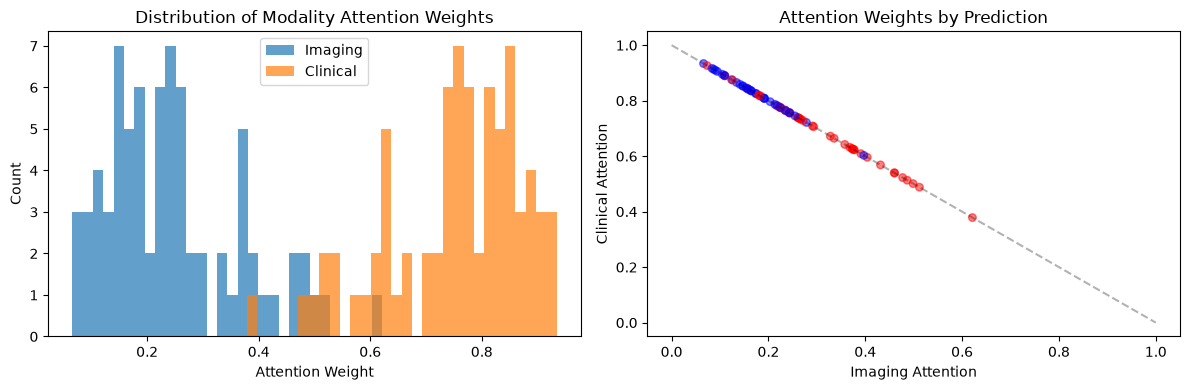

In [17]:
# Visualize attention distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of attention weights
axes[0].hist(attention_weights[:, 0], bins=30, alpha=0.7, label='Imaging')
axes[0].hist(attention_weights[:, 1], bins=30, alpha=0.7, label='Clinical')
axes[0].set_xlabel('Attention Weight')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Modality Attention Weights')
axes[0].legend()

# Scatter plot: attention vs prediction
colors = ['blue' if p == 0 else 'red' for p in all_predictions]
axes[1].scatter(attention_weights[:, 0], attention_weights[:, 1], 
                c=colors, alpha=0.5, s=30)
axes[1].set_xlabel('Imaging Attention')
axes[1].set_ylabel('Clinical Attention')
axes[1].set_title('Attention Weights by Prediction')
axes[1].plot([0, 1], [1, 0], 'k--', alpha=0.3)  # diagonal reference

plt.tight_layout()
plt.show()

### Reading the Visualizations

> **Reminder**: These "attention weights" are **modality importance scores** (α for imaging, β for clinical, where α + β = 1) - a simple gated fusion mechanism, not transformer self-attention. They tell us how much the model relies on each data source for each patient.

**Left Plot (Histogram of Attention Weights)**:

*What it shows*: The distribution of attention weights across all validation patients. Two overlapping histograms: blue = imaging attention (α), orange = clinical attention (β).

*How to read it*:
- **X-axis**: Attention weight value (0 to 1)
- **Y-axis**: Count of patients with that weight
- **Peak location**: Where most patients' weights fall
- **Spread**: How variable the weights are across patients

*Observations*:
- Orange bars (clinical) cluster around 0.7 → model consistently relies more on clinical data
- Blue bars (imaging) cluster around 0.3 → imaging is supplementary
- Narrow distributions → model is confident about the relative importance

**Right Plot (Scatter of Attention Weights)**:

*What it shows*: Each point is a patient, positioned by their imaging attention (x-axis) vs. clinical attention (y-axis), colored by the model's prediction.

*How to read it*:
- The dashed diagonal line represents α + β = 1 (all points must lie on this line)
- Blue points = predicted Poor outcome; Red points = predicted Good outcome
- Clustering by color reveals if the model uses different attention patterns for different predictions

*Observations*:
- Points lie along the diagonal (α + β = 1 constraint, as expected)
- If Blue and Red points cluster in different regions, the model uses modality-specific cues for each outcome class
- If points are mixed, the model uses similar fusion regardless of prediction

### Clinical Implications

If this were a real clinical model:
- **High clinical attention** suggests age and lab values drive prognosis
- **Lower imaging attention** doesn't mean imaging is useless—it provides complementary information
- The model could be explained to clinicians: *"For this patient, 72% of the prediction comes from clinical factors"*

<details>
<summary><b>Interpreting the Attention Weights</b> (click to expand)</summary>

### What the Numbers Tell Us

From the output above:
- **Mean Imaging Attention (α)**: ~0.28
- **Mean Clinical Attention (β)**: ~0.72

The model learned to weight **clinical features ~2.5× more than imaging features**. This makes sense given our ground truth label generation:

```python
risk_score = 0.3 × mean(imaging[:5]) + 0.02 × age + 0.2 × clin_feat_0
```

Why clinical dominates:
- Age ranges from 20-80, so `0.02 × age` contributes up to ~1.2 to the risk score
- Imaging mean of N(0,1) features contributes ~0.3 × small_value
- The model correctly learned that age (a clinical feature) is the strongest predictor

### Validating the Model's "Reasoning"

This is a powerful feature of interpretable architectures: we can **verify** that the model found the true signal. Since we know the synthetic data generation formula, we can confirm:

| Ground Truth | Model Learned |
|--------------|---------------|
| Age (clinical) is strongest predictor | Clinical attention ~72% |
| Imaging contributes less | Imaging attention ~28% |
| Both modalities matter | Neither weight is 0 |

In real applications, we can't directly validate like this—but domain experts can assess whether the attention patterns are clinically plausible.

### Clinical Implications

If this were a real clinical model:
- **High clinical attention** suggests age and lab values drive prognosis
- **Lower imaging attention** doesn't mean imaging is useless—it provides complementary information
- The model could be explained to clinicians: *"For this patient, 72% of the prediction comes from clinical factors"*

### Cautions and Limitations

- These weights show **learned importance**, not causal influence
- A feature receiving low attention may still be critical in edge cases
- Attention weights can be manipulated by adversarial inputs
- Always validate with domain expertise and external datasets

</details>

<details>
<summary><b>Exercise: Implementing 3-Way Attention</b> (click to expand)</summary>

### Challenge

Our 2-way attention (imaging vs. clinical) treats all clinical features as one bundle. But we know from the ground truth that **age** is the dominant clinical predictor. Can we separate it?

### Sketch: TrimodalFusionNet

```python
class TrimodalFusionNet(nn.Module):
    """3-way attention: imaging / age / other clinical."""
    
    def __init__(self, imaging_dim=50, clinical_dim=9, hidden_dim=64):
        super().__init__()
        
        # Three separate encoders
        self.imaging_encoder = nn.Sequential(
            nn.Linear(imaging_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
        self.age_encoder = nn.Sequential(
            nn.Linear(1, hidden_dim // 4),  # Age is just 1 feature
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, hidden_dim)
        )
        
        self.clinical_encoder = nn.Sequential(
            nn.Linear(clinical_dim, hidden_dim // 2),  # 9 other features
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim)
        )
        
        # 3-way attention (outputs α, β, γ that sum to 1)
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 3),  # 3 weights instead of 2
            nn.Softmax(dim=1)
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 2)
        )
    
    def forward(self, imaging, age, clinical):
        # Encode each modality
        img_enc = self.imaging_encoder(imaging)
        age_enc = self.age_encoder(age)  # age shape: (batch, 1)
        clin_enc = self.clinical_encoder(clinical)
        
        # Compute 3-way attention
        combined = torch.cat([img_enc, age_enc, clin_enc], dim=1)
        attn = self.attention(combined)  # (batch, 3)
        
        # Weighted fusion: α*img + β*age + γ*clin
        fused = (attn[:, 0:1] * img_enc + 
                 attn[:, 1:2] * age_enc + 
                 attn[:, 2:3] * clin_enc)
        
        return self.classifier(fused), attn
```

### Data Preparation Changes

```python
# Split clinical features into age and other
age = X_clin[:, 0:1]           # Shape: (n, 1)
other_clinical = X_clin[:, 1:]  # Shape: (n, 9) - sex + biomarkers

# Create 3-input TensorDataset
dataset = TensorDataset(
    torch.FloatTensor(X_img),
    torch.FloatTensor(age),
    torch.FloatTensor(other_clinical),
    torch.LongTensor(y)
)
```

### Expected Results

With 3-way attention, you should observe:
- **β (age attention) ≈ 0.5-0.7** — Age is the strongest single predictor
- **α (imaging attention) ≈ 0.2-0.3** — Imaging contributes moderately
- **γ (other clinical attention) ≈ 0.1-0.2** — Includes the biomarker effect

This matches the ground truth: age has the largest contribution due to its wide range (20-80).

### Discussion Questions

1. When would 3-way (or N-way) attention be worth the added complexity?
2. How would you extend this to handle missing modalities (e.g., patient has no imaging)?
3. Could you make attention weights **feature-level** instead of modality-level?

</details>

## 7. Patient Similarity Network

### From Classification to Discovery: The Analysis Pipeline

So far, we've built a complete **supervised learning pipeline**:

| Section | What We Did | Output |
|---------|-------------|--------|
| **4. Multimodal Fusion** | Built an adaptive fusion model to combine imaging + clinical features | Trained model with learned representations |
| **5. Training** | Optimized the model to predict survival outcomes | ~90% accuracy, ~0.98 AUC |
| **6. Attention Analysis** | Examined which modality the model relies on | Clinical features dominate (α≈0.28, β≈0.72) |

But supervised classification answers only one question: *"What is this patient's predicted outcome?"*

**Patient Similarity Networks** answer a different, complementary question: *"Which other patients are most similar to this one?"*

### Why Move from Classification to Similarity?

```
┌─────────────────────────────────────────────────────────────────────┐
│  SUPERVISED CLASSIFICATION          UNSUPERVISED DISCOVERY          │
│  (Sections 4-6)                     (Section 7)                     │
│                                                                     │
│  Input: Imaging + Clinical    →     Use learned representations     │
│  Output: Predicted label      →     Find similar patients           │
│  Question: Will outcome be    →     Who else looks like this        │
│            poor or good?            patient?                        │
│                                                                     │
│  ┌─────────────┐                    ┌─────────────┐                 │
│  │   Patient   │ ──Fusion Model──→  │  Embedded   │ ──Similarity──→ │
│  │   Features  │                    │  Features   │    Network      │
│  └─────────────┘                    └─────────────┘                 │
└─────────────────────────────────────────────────────────────────────┘
```

The key insight: our **fusion model learned meaningful representations** of patients. We can repurpose these embeddings to measure patient-to-patient similarity, even without using the classification head.

### What is a Patient Similarity Network?

A **Patient Similarity Network (PSN)** is a graph-based representation where:
- **Nodes** represent individual patients
- **Edges** connect patients with similar multimodal profiles
- **Edge weights** reflect the degree of similarity

PSNs enable powerful downstream analyses that complement traditional supervised classification:

| Application | Description | Clinical Value |
|------------|-------------|----------------|
| **Cohort Identification** | Discover patient subgroups with similar characteristics | Identify patients who may respond similarly to treatment |
| **Outcome Prediction** | Predict outcomes based on similar patients | Leverage historical outcomes from similar cases |
| **Drug Repurposing** | Find patients with similar profiles who responded to treatments | Suggest treatments based on similar patient outcomes |
| **Missing Data Imputation** | Impute missing values from similar patients | Improve data completeness for model training |

### Why Use Multimodal Features for Similarity?

Patient similarity computed from **fused multimodal features** captures a more holistic patient representation than any single modality:

- **Imaging features alone** may miss important clinical context (e.g., age, comorbidities)
- **Clinical features alone** may miss subtle phenotypic patterns visible in imaging
- **Combined features** capture complementary information, leading to more clinically meaningful similarity

---

### Similarity Metrics

Different similarity metrics capture different aspects of patient relationships:

| Metric | Formula | Best For |
|--------|---------|----------|
| **Cosine Similarity** | $\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$ | High-dimensional, sparse features; direction matters more than magnitude |
| **Euclidean Similarity** | $1 / (1 + d(\mathbf{A}, \mathbf{B}))$ | When absolute feature values matter |
| **Correlation** | Pearson/Spearman correlation | When relative ordering of features is important |

We use **cosine similarity** here because:
1. Our features are standardized (zero mean, unit variance)
2. We care about feature *profiles* rather than absolute magnitudes
3. Cosine similarity is robust to scaling differences between modalities


In [18]:
def compute_similarity_matrix(features, method='cosine'):
    """Compute patient similarity matrix."""
    from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
    
    if method == 'cosine':
        sim = cosine_similarity(features)
    elif method == 'euclidean':
        dist = euclidean_distances(features)
        sim = 1 / (1 + dist)  # Convert distance to similarity
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return sim

In [19]:
# Combine features for similarity computation
combined_features = np.hstack([
    img_scaler.transform(data['imaging']),
    clin_scaler.transform(data['clinical'])
])

# Compute similarity matrix
sim_matrix = compute_similarity_matrix(combined_features, method='cosine')
print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Similarity range: [{sim_matrix.min():.3f}, {sim_matrix.max():.3f}]")

Similarity matrix shape: (500, 500)
Similarity range: [-0.833, 1.000]


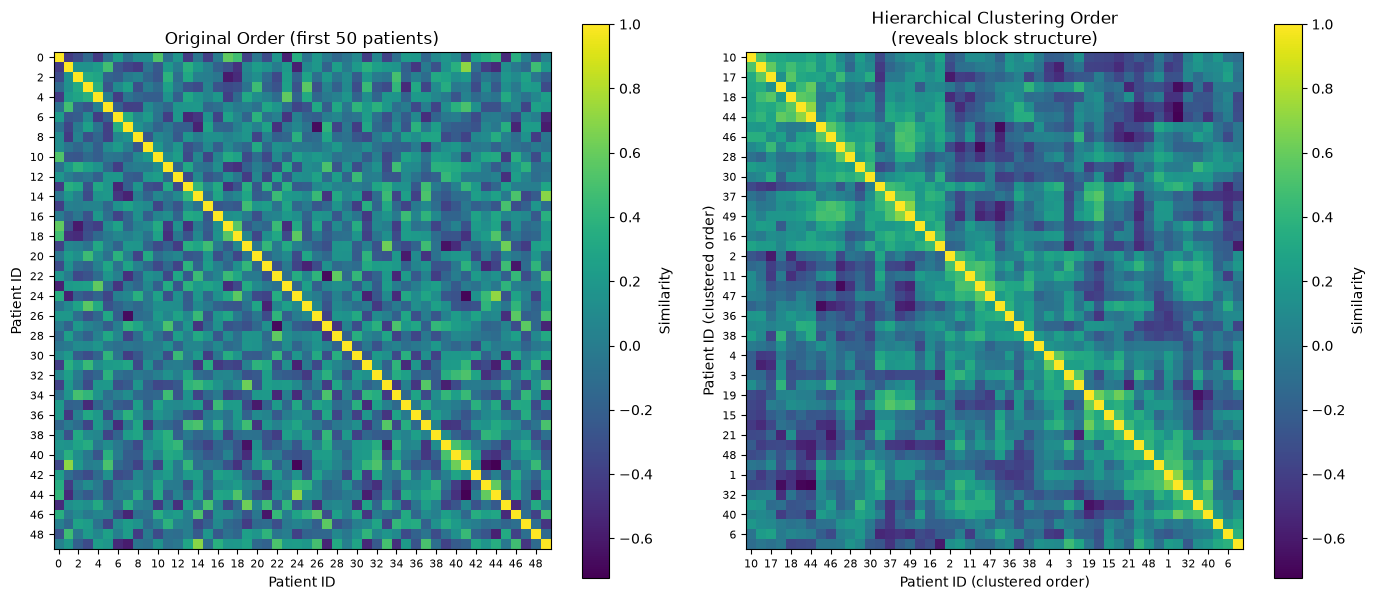


Clustered order (first 10 patients): [np.int32(10), np.int32(0), np.int32(17), np.int32(43), np.int32(18), np.int32(24), np.int32(44), np.int32(26), np.int32(46), np.int32(22)]
Patients adjacent in this ordering have similar multimodal profiles.
Block-diagonal patterns in the right heatmap indicate distinct patient subgroups.


In [20]:
# Visualize similarity matrix - original and reordered
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

# Subset of patients to visualize
n_show = 50
sim_subset = sim_matrix[:n_show, :n_show]

# Hierarchical clustering to find optimal ordering
# Convert similarity to distance (1 - similarity), ensure non-negative
dist_matrix = 1 - sim_subset
np.fill_diagonal(dist_matrix, 0)  # Ensure diagonal is exactly 0
dist_matrix = np.clip(dist_matrix, 0, None)  # Clip any negative values

# Get condensed distance matrix for linkage
dist_condensed = squareform(dist_matrix, checks=False)
linkage_matrix = linkage(dist_condensed, method='average')
optimal_order = leaves_list(linkage_matrix)

# Reorder the similarity matrix
sim_reordered = sim_subset[np.ix_(optimal_order, optimal_order)]

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tick formatting settings (show every 2nd patient for denser labeling)
tick_step = 2
tick_positions = np.arange(0, n_show, tick_step)

# Left: Original ordering
im0 = axes[0].imshow(sim_subset, cmap='viridis')
plt.colorbar(im0, ax=axes[0], label='Similarity')
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_positions, fontsize=8)
axes[0].set_yticks(tick_positions)
axes[0].set_yticklabels(tick_positions, fontsize=8)

axes[0].set_xlabel('Patient ID')
axes[0].set_ylabel('Patient ID')
axes[0].set_title(f'Original Order (first {n_show} patients)')

# Right: Reordered by hierarchical clustering (with original patient IDs)
im1 = axes[1].imshow(sim_reordered, cmap='viridis')
plt.colorbar(im1, ax=axes[1], label='Similarity')

# Show original patient IDs on the axes
tick_labels = [str(optimal_order[i]) for i in tick_positions]
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, fontsize=8)
axes[1].set_yticks(tick_positions)
axes[1].set_yticklabels(tick_labels, fontsize=8)

axes[1].set_xlabel('Patient ID (clustered order)')
axes[1].set_ylabel('Patient ID (clustered order)')
axes[1].set_title(f'Hierarchical Clustering Order\n(reveals block structure)')

plt.tight_layout()
plt.show()

print(f"\nClustered order (first 10 patients): {list(optimal_order[:10])}")
print("Patients adjacent in this ordering have similar multimodal profiles.")
print("Block-diagonal patterns in the right heatmap indicate distinct patient subgroups.")

---

### Reading the PSN Visualizations

#### Patient Similarity Matrix (Heatmaps)

We show two versions of the same similarity matrix:

**Left: Original Order**
- Patients appear in their original index order (0, 1, 2, ...)
- Structure may be hidden because similar patients are scattered across the matrix
- Useful for identifying specific patient pairs by their IDs

**Right: Hierarchical Clustering Order**
- Patients are **reordered** so that similar patients are adjacent
- Uses **average-linkage hierarchical clustering** on the distance matrix (1 - similarity)
- **Block-diagonal patterns** emerge, revealing natural patient subgroups
- The size and number of blocks indicate how many distinct patient phenotypes exist

**How to read both heatmaps**:
- **Color scale** (viridis): Yellow = high similarity (~1.0), purple = low similarity (~0.0)
- **Diagonal**: Always brightest (self-similarity = 1.0)
- **Symmetric**: Cell (i,j) = Cell (j,i)

**What to look for in the reordered heatmap**:
- **Clear blocks along diagonal**: Strong evidence of patient subgroups with distinct multimodal profiles
- **Block size**: Larger blocks = more patients in that subgroup
- **Off-diagonal brightness**: High similarity between different subgroups (potential for merging)
- **Fuzzy boundaries**: Gradual transitions suggest continuous variation rather than discrete subtypes

---

### Key Takeaways: Patient Similarity Networks

> **Clinical Relevance**: PSNs provide an intuitive, interpretable view of how patients relate to each other based on their multimodal profiles. This can support:
> - **Precision medicine**: Identifying patients who may respond similarly to treatments
> - **Subtype discovery**: Finding novel patient subgroups not captured by existing classifications
> - **Outcome prediction**: Using similar patients' outcomes to inform prognosis

**Limitations of our synthetic data demonstration**:
- Real clinical cohorts have more complex, non-linear relationships
- Community structure may be less clear with real biological variability
- Clinical validation is essential before using PSNs for patient care decisions


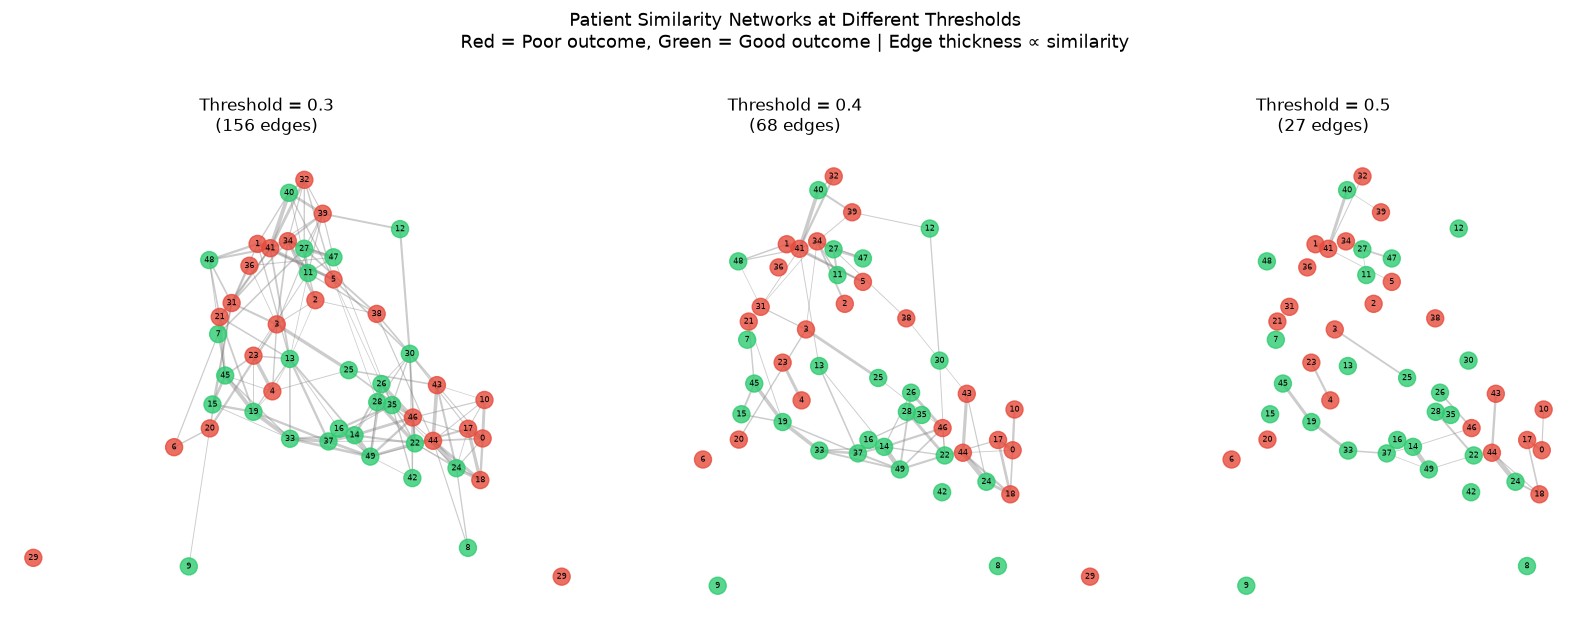


Threshold comparison:
--------------------------------------------------
  Threshold 0.3: 156 edges, avg degree = 6.2
  Threshold 0.4:  68 edges, avg degree = 2.7
  Threshold 0.5:  27 edges, avg degree = 1.1
--------------------------------------------------

Lower threshold → more edges → denser network (may obscure structure)
Higher threshold → fewer edges → sparser network (may miss connections)
Choose threshold that reveals clusters without becoming a 'hairball'.


In [21]:
# Network visualization - comparing different similarity thresholds
# Using same 50 patients as heatmaps above

import networkx as nx

# Use the same subset as the heatmaps (first 50 patients)
n_network = 50
sim_network = sim_matrix[:n_network, :n_network]
labels_network = data['labels'][:n_network]

# Node colors by outcome (consistent across all panels)
node_colors = ['#e74c3c' if labels_network[i] == 0 else '#2ecc71' for i in range(n_network)]

def build_network_at_threshold(sim_mat, thresh):
    """Build a network and return graph, edges with weights, and edge count."""
    G = nx.Graph()
    G.add_nodes_from(range(len(sim_mat)))
    edges_with_weights = []
    for i in range(len(sim_mat)):
        for j in range(i+1, len(sim_mat)):
            sim = sim_mat[i, j]
            if sim > thresh:
                edges_with_weights.append((i, j, sim))
                G.add_edge(i, j, weight=sim)
    return G, edges_with_weights

# Compare three thresholds to show effect on network structure
thresholds = [0.3, 0.4, 0.5]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Use consistent layout based on lowest threshold (most edges)
G_base, _ = build_network_at_threshold(sim_network, thresholds[0])
pos = nx.spring_layout(G_base, seed=42, k=1.5/np.sqrt(n_network))

for idx, thresh in enumerate(thresholds):
    ax = axes[idx]
    G, edges_with_weights = build_network_at_threshold(sim_network, thresh)
    n_edges = len(edges_with_weights)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=150, alpha=0.8, ax=ax)
    
    # Draw edges with width proportional to similarity
    if len(edges_with_weights) > 0:
        edges = [(e[0], e[1]) for e in edges_with_weights]
        weights = [e[2] for e in edges_with_weights]
        # Scale weights to visible line widths
        min_w, max_w = min(weights), max(weights)
        if max_w > min_w:
            scaled_widths = [0.5 + 3.0 * (w - min_w) / (max_w - min_w) for w in weights]
        else:
            scaled_widths = [1.5] * len(weights)
        
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=scaled_widths, 
                               alpha=0.4, edge_color='gray', ax=ax)
    
    # Draw node labels (smaller font for clarity)
    nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
    
    ax.set_title(f'Threshold = {thresh}\n({n_edges} edges)', fontsize=12)
    ax.axis('off')

plt.suptitle('Patient Similarity Networks at Different Thresholds\n'
             'Red = Poor outcome, Green = Good outcome | Edge thickness ∝ similarity',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print summary
print("\nThreshold comparison:")
print("-" * 50)
for thresh in thresholds:
    _, edges = build_network_at_threshold(sim_network, thresh)
    avg_degree = 2 * len(edges) / n_network
    print(f"  Threshold {thresh}: {len(edges):3d} edges, avg degree = {avg_degree:.1f}")
print("-" * 50)
print("\nLower threshold → more edges → denser network (may obscure structure)")
print("Higher threshold → fewer edges → sparser network (may miss connections)")
print("Choose threshold that reveals clusters without becoming a 'hairball'.")

### Interpreting the Threshold Comparison

The three panels above show the **same 50 patients** (matching the heatmaps) as network graphs, but with different similarity thresholds determining which edges are drawn.

#### Understanding the Threshold Parameter

| Threshold | Edges | Avg Degree | Interpretation |
|-----------|-------|------------|----------------|
| **0.3** (left) | ~156 | ~6.2 | Low bar for connection → dense network, many weak links visible |
| **0.4** (middle) | ~68 | ~2.7 | Moderate → balanced view of structure |
| **0.5** (right) | ~27 | ~1.1 | High bar → only strongest similarities shown, sparse network |

**Edge threshold** means: "Only draw a connection between two patients if their cosine similarity exceeds this value."

#### What to Look For

1. **Cluster formation**: Do patients naturally group together? At threshold 0.3-0.4, you can see distinct clusters emerging—these correspond to the **block-diagonal structure** in the reordered heatmap.

2. **Outcome segregation**: Are red nodes (Poor outcome) and green nodes (Good outcome) separating into different regions? 
   - **Strong segregation** → multimodal features capture outcome-relevant information
   - **Mixed clusters** → features may capture other patient characteristics, or outcomes are harder to predict from these features alone

3. **Hub patients**: Some nodes have many connections (high degree)—these patients have multimodal profiles similar to many others. They may represent "typical" cases for their subgroup.

4. **Isolated nodes**: Patients with few or no connections (especially at higher thresholds) have unique profiles. They may be outliers worth clinical attention.

#### Connecting to the Heatmaps

The networks visualize the **same similarity information** as the heatmaps, but in a different representation:

| Heatmap View | Network View |
|--------------|--------------|
| Bright yellow cell at (i, j) | Thick edge between nodes i and j |
| Block-diagonal pattern | Cluster of densely connected nodes |
| Dark purple regions | Absence of edges between those patients |

The **reordered heatmap** (right panel above) groups similar patients together—these same groups appear as **clusters** in the network visualization.

#### Choosing the Right Threshold

There's no single "correct" threshold—it depends on your analytical goal:

- **Exploratory analysis**: Use lower threshold (0.3-0.4) to see more structure
- **Identifying core subgroups**: Use higher threshold (0.5+) to find only the strongest relationships
- **Clinical decision support**: Match threshold to clinically meaningful similarity (requires domain expertise)

For this synthetic dataset, **threshold ≈ 0.4** provides a good balance: enough edges to see cluster structure, but not so many that the visualization becomes cluttered.

---

### Community Detection: From Pairs to Subgroups

The similarity network above shows pairwise relationships, but the real power comes from identifying **communities**—groups of patients who are all similar to each other.

```
Pipeline so far:
                                                                        
  Raw Features → Fusion Model → Embeddings → Similarity → Network → ???
  (Sec 2-3)      (Sec 4)        (learned)    (pairwise)   (graph)       
                                                                        
Next step: Community Detection → Patient Subgroups
```

**Community detection** algorithms identify clusters of densely connected nodes within the network. In the context of PSNs, communities represent **patient subgroups** with similar multimodal profiles.

| What Communities Reveal | Clinical Application |
|-------------------------|---------------------|
| Patients who cluster together | May respond similarly to treatment |
| Separation between communities | Potential disease subtypes |
| Outlier patients (no community) | Unusual cases requiring special attention |

This is a form of **unsupervised learning** that can:
- Discover novel patient subtypes not captured by existing labels
- Validate that known clinical subtypes form distinct communities
- Identify patients who may benefit from similar treatment strategies

We use the **Louvain algorithm**, which optimizes *modularity*—a measure of how well the network is partitioned into communities compared to a random graph.

> **Important**: For meaningful community detection, the network must be **sufficiently connected**. Key guidelines:
> - **Average degree ≥ 2**: Each node should have at least 2 connections on average
> - **Few isolated nodes**: Disconnected nodes become singleton "communities" (not useful)
> - **Consistent with visualizations**: Use the same patients and similar threshold as the network plots above
>
> If you detect nearly as many communities as nodes, the graph is too sparse—lower the threshold.

<details>
<summary><b>Technical Note: The Louvain Algorithm and Modularity</b> (click to expand)</summary>

#### Modularity: The Optimization Target

**Modularity** ($Q$) quantifies how well a network is partitioned into communities. It compares the actual edge density within communities to the expected density in a random graph with the same degree distribution:

$$Q = \frac{1}{2m} \sum_{ij} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

Where:
- $A_{ij}$ = adjacency matrix (1 if edge between $i$ and $j$, else 0)
- $k_i, k_j$ = degree (number of connections) of nodes $i$ and $j$
- $m$ = total number of edges in the network
- $c_i, c_j$ = community assignments of nodes $i$ and $j$
- $\delta(c_i, c_j)$ = 1 if $c_i = c_j$ (same community), else 0

**Interpretation**:
- $Q > 0$: More edges within communities than expected by chance
- $Q \approx 0$: No community structure (random-like)
- $Q$ typically ranges from 0.3 to 0.7 for networks with clear community structure

#### The Louvain Algorithm

The Louvain method ([Blondel et al., 2008](https://arxiv.org/abs/0803.0476)) is a greedy, hierarchical algorithm:

1. **Phase 1 (Local optimization)**: Each node starts in its own community. Iteratively move each node to the neighboring community that yields the greatest modularity gain. Repeat until no improvement.

2. **Phase 2 (Aggregation)**: Collapse each community into a single "super-node," creating a new, smaller network.

3. **Repeat**: Apply Phase 1 to the aggregated network. Continue until modularity no longer increases.

**Advantages**:
- Fast: $O(n \log n)$ complexity for sparse networks
- No need to specify number of communities in advance
- Produces hierarchical community structure

**Limitations**:
- **Non-deterministic by default**: The algorithm processes nodes in random order, and when multiple moves yield equal modularity gain, ties are broken randomly. However, this can be controlled by setting a `random_state` seed for reproducible results.
- **Resolution limit**: May fail to detect small communities in large networks (communities smaller than $\sqrt{m/2}$ where $m$ is edge count)
- **Greedy**: Not guaranteed to find global optimum—different random seeds may yield different (but similarly good) partitions

#### Is Number of Communities Related to Q?

**No, not directly.** Modularity Q measures *quality* of the partition, not *quantity* of communities:

| Scenario | Number of Communities | Q Value |
|----------|----------------------|---------|
| All nodes in one community | 1 | Q ≈ 0 (no structure detected) |
| Each node in its own community | n | Q ≈ 0 (no grouping benefit) |
| Optimal partition | k (data-dependent) | Q = maximum |

The Louvain algorithm finds the number of communities that **maximizes Q**. Adding more communities beyond the optimum *decreases* Q because you're splitting naturally cohesive groups. Fewer communities than optimal also decreases Q because you're merging dissimilar nodes.

```
Q
↑
│         ╭──────╮
│        ╱        ╲
│       ╱          ╲
│      ╱            ╲
│     ╱              ╲
│    ╱                ╲
└───┴──────────────────┴──→ Number of communities
    1        k*         n
           (optimal)
```

**Key insight**: A network with 5 well-separated communities can have higher Q than one with 20 fuzzy communities. Q rewards *dense within-community connections* and *sparse between-community connections*, regardless of how many communities exist.

#### Clinical Considerations

When applying Louvain to Patient Similarity Networks:
- Communities are **data-driven**—they may or may not align with known clinical subtypes
- High modularity suggests distinct patient phenotypes exist in the data
- Communities found should be **validated** against clinical outcomes or expert knowledge
- Consider running multiple times and checking stability of community assignments

</details>

In [22]:
# Community detection using Louvain algorithm
import networkx as nx
try:
    from community import community_louvain
    HAS_COMMUNITY = True
except ImportError:
    HAS_COMMUNITY = False
    print("Note: python-louvain not installed. Install with: pip install python-louvain")

def build_similarity_graph(sim_matrix, threshold=0.5, max_nodes=100):
    """Build a NetworkX graph from similarity matrix."""
    n_nodes = min(sim_matrix.shape[0], max_nodes)
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))
    
    for i in range(n_nodes):
        for j in range(i+1, n_nodes):
            if sim_matrix[i, j] > threshold:
                G.add_edge(i, j, weight=sim_matrix[i, j])
    
    return G

# Build the graph - use same 50 patients as heatmaps for consistency
# Use threshold=0.4 for reasonable connectivity (see threshold comparison above)
n_patients_community = 50
threshold_community = 0.4

G = build_similarity_graph(sim_matrix, threshold=threshold_community, max_nodes=n_patients_community)
n_edges = G.number_of_edges()
avg_degree = 2 * n_edges / G.number_of_nodes() if G.number_of_nodes() > 0 else 0

print(f"Graph for community detection:")
print(f"  Nodes: {G.number_of_nodes()} (same patients as heatmaps above)")
print(f"  Edges: {n_edges} (threshold = {threshold_community})")
print(f"  Average degree: {avg_degree:.1f}")

if avg_degree < 2:
    print(f"\n⚠️ Warning: Average degree < 2 means many isolated nodes.")
    print(f"   Consider lowering threshold for more meaningful community detection.")

Graph for community detection:
  Nodes: 50 (same patients as heatmaps above)
  Edges: 68 (threshold = 0.4)
  Average degree: 2.7


In [23]:
# Detect communities
if HAS_COMMUNITY:
    # Use random_state for reproducibility (Louvain has stochastic node ordering)
    partition = community_louvain.best_partition(G, random_state=SEED)
    n_communities = len(set(partition.values()))
    print(f"Detected {n_communities} communities")
    
    # Analyze community composition
    print("\nCommunity composition by outcome:")
    print("-" * 40)
    for comm_id in range(n_communities):
        members = [node for node, comm in partition.items() if comm == comm_id]
        if len(members) > 0:
            labels_in_comm = data['labels'][members]
            poor_pct = (labels_in_comm == 0).sum() / len(members) * 100
            good_pct = (labels_in_comm == 1).sum() / len(members) * 100
            print(f"Community {comm_id}: {len(members):3d} patients | "
                  f"Poor outcome: {poor_pct:5.1f}% | Good outcome: {good_pct:5.1f}%")
else:
    print("Community detection skipped (python-louvain not installed)")
    partition = None

Detected 15 communities

Community composition by outcome:
----------------------------------------
Community 0:   1 patients | Poor outcome: 100.0% | Good outcome:   0.0%
Community 1:   1 patients | Poor outcome:   0.0% | Good outcome: 100.0%
Community 2:   6 patients | Poor outcome:  50.0% | Good outcome:  50.0%
Community 3:   3 patients | Poor outcome:  66.7% | Good outcome:  33.3%
Community 4:   2 patients | Poor outcome: 100.0% | Good outcome:   0.0%
Community 5:   1 patients | Poor outcome: 100.0% | Good outcome:   0.0%
Community 6:   1 patients | Poor outcome:   0.0% | Good outcome: 100.0%
Community 7:   1 patients | Poor outcome:   0.0% | Good outcome: 100.0%
Community 8:   1 patients | Poor outcome:   0.0% | Good outcome: 100.0%
Community 9:  10 patients | Poor outcome:  60.0% | Good outcome:  40.0%
Community 10:   9 patients | Poor outcome:  11.1% | Good outcome:  88.9%
Community 11:   4 patients | Poor outcome:  25.0% | Good outcome:  75.0%
Community 12:   2 patients | Poor 

Observed Modularity Q = 0.6432

Running permutation test (100 random graphs)...

Modularity Analysis Results:
  Observed Q:           0.6432
  Null distribution:    0.4991 ± 0.0255 (mean ± std)
  95th percentile null: 0.5359
  Z-score:              5.65
  p-value:              0.0000
✓ Observed modularity significantly exceeds random expectation (p < 0.05)
  The patient similarity network has meaningful community structure.


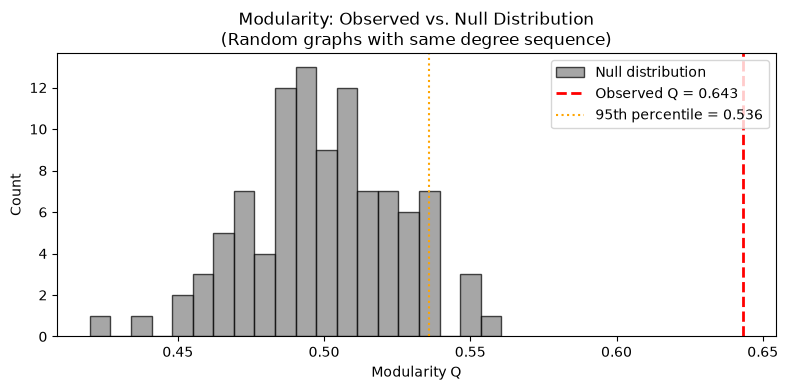

In [24]:
# Compute modularity Q and assess statistical significance
if HAS_COMMUNITY and partition is not None:
    from networkx.algorithms.community import modularity
    
    # Convert partition dict to list of sets (required by networkx)
    communities = {}
    for node, comm_id in partition.items():
        if comm_id not in communities:
            communities[comm_id] = set()
        communities[comm_id].add(node)
    community_sets = list(communities.values())
    
    # Calculate observed modularity
    Q_observed = modularity(G, community_sets)
    print(f"Observed Modularity Q = {Q_observed:.4f}")
    print()
    
    # Permutation test: compare to null distribution
    # Null hypothesis: no community structure (random edge rewiring)
    n_permutations = 100
    Q_null = []
    
    print(f"Running permutation test ({n_permutations} random graphs)...")
    for i in range(n_permutations):
        # Create random graph with same degree sequence (configuration model)
        try:
            G_random = nx.configuration_model([d for n, d in G.degree()], seed=i)
            G_random = nx.Graph(G_random)  # Remove multi-edges
            G_random.remove_edges_from(nx.selfloop_edges(G_random))  # Remove self-loops
            
            if G_random.number_of_edges() > 0:
                # Detect communities in random graph
                partition_random = community_louvain.best_partition(G_random, random_state=i)
                communities_random = {}
                for node, comm_id in partition_random.items():
                    if comm_id not in communities_random:
                        communities_random[comm_id] = set()
                    communities_random[comm_id].add(node)
                community_sets_random = list(communities_random.values())
                
                Q_random = modularity(G_random, community_sets_random)
                Q_null.append(Q_random)
        except:
            continue  # Skip failed random graph generations
    
    Q_null = np.array(Q_null)
    
    # Compute statistics
    Q_mean_null = Q_null.mean()
    Q_std_null = Q_null.std()
    z_score = (Q_observed - Q_mean_null) / Q_std_null if Q_std_null > 0 else np.inf
    p_value = (Q_null >= Q_observed).sum() / len(Q_null)
    
    # 95% confidence interval for null distribution
    Q_null_95 = np.percentile(Q_null, 95)
    
    print(f"\nModularity Analysis Results:")
    print("=" * 50)
    print(f"  Observed Q:           {Q_observed:.4f}")
    print(f"  Null distribution:    {Q_mean_null:.4f} ± {Q_std_null:.4f} (mean ± std)")
    print(f"  95th percentile null: {Q_null_95:.4f}")
    print(f"  Z-score:              {z_score:.2f}")
    print(f"  p-value:              {p_value:.4f}")
    print("=" * 50)
    
    if Q_observed > Q_null_95:
        print(f"✓ Observed modularity significantly exceeds random expectation (p < 0.05)")
        print(f"  The patient similarity network has meaningful community structure.")
    else:
        print(f"✗ Observed modularity not significantly different from random graphs.")
        print(f"  Community structure may be weak or spurious.")
    
    # Visualize null distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(Q_null, bins=20, alpha=0.7, color='gray', edgecolor='black', label='Null distribution')
    ax.axvline(Q_observed, color='red', linewidth=2, linestyle='--', label=f'Observed Q = {Q_observed:.3f}')
    ax.axvline(Q_null_95, color='orange', linewidth=1.5, linestyle=':', label=f'95th percentile = {Q_null_95:.3f}')
    ax.set_xlabel('Modularity Q')
    ax.set_ylabel('Count')
    ax.set_title('Modularity: Observed vs. Null Distribution\n(Random graphs with same degree sequence)')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Modularity analysis skipped (requires community detection results)")

<details>
<summary><b>Interpreting the Modularity Significance Test</b> (click to expand)</summary>

### Why Test Modularity Significance?

Finding communities in a network doesn't automatically mean the structure is meaningful. Even random networks can be partitioned into "communities" by algorithms like Louvain. The key question is: **Is our observed modularity higher than what we'd expect by chance?**

### The Permutation Test Approach

We use a **permutation test** to assess significance:

1. **Observed Q**: Calculate modularity of the actual patient similarity network
2. **Null distribution**: Generate 100 random graphs with the same degree sequence (using the configuration model), detect communities in each, and compute their modularities
3. **Compare**: If observed Q exceeds the 95th percentile of the null distribution, the community structure is statistically significant (p < 0.05)

### Interpreting Results

| Outcome | Interpretation |
|---------|----------------|
| **Q_observed >> Q_null** | Strong evidence of meaningful community structure |
| **Q_observed ≈ Q_null** | Community structure may be an artifact of the algorithm |
| **High Z-score (>2)** | Observed modularity is many standard deviations above random |

### Clinical Implications

- **Significant modularity** suggests that patient subgroups identified by the Louvain algorithm are **real** (not just algorithmic artifacts)
- These subgroups may represent distinct clinical phenotypes worth investigating
- However, statistical significance ≠ clinical relevance—validation with outcomes is still needed

### Limitations

- The null model (configuration model) preserves degree distribution but not other network properties
- Results depend on the similarity threshold used to construct the network
- Multiple testing: if you try many thresholds, p-values need adjustment

</details>

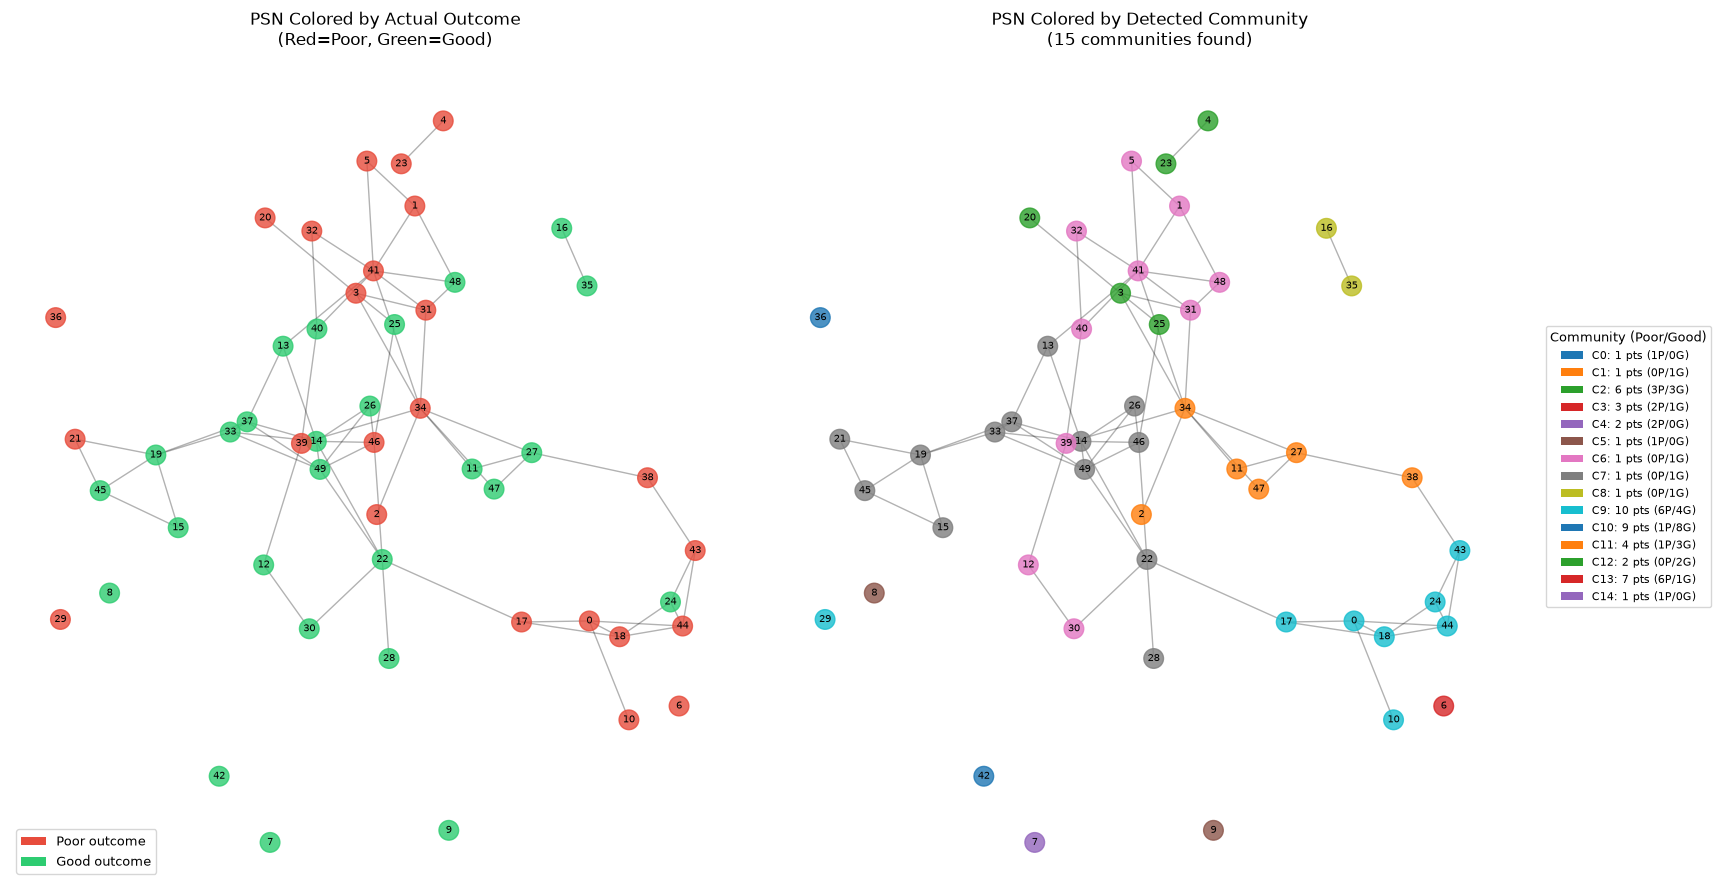

In [25]:
# Visualize communities
if HAS_COMMUNITY and partition is not None:
    fig, axes = plt.subplots(1, 2, figsize=(18, 9))
    
    # Left: Color by actual outcome
    pos = nx.spring_layout(G, seed=42, k=2/np.sqrt(G.number_of_nodes()))
    outcome_colors = ['#e74c3c' if data['labels'][i] == 0 else '#2ecc71' 
                      for i in range(G.number_of_nodes())]
    nx.draw_networkx_nodes(G, pos, node_color=outcome_colors, 
                           node_size=200, alpha=0.8, ax=axes[0])
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=axes[0])
    nx.draw_networkx_labels(G, pos, font_size=7, font_color='black', ax=axes[0])
    axes[0].set_title('PSN Colored by Actual Outcome\n(Red=Poor, Green=Good)', fontsize=12)
    axes[0].axis('off')
    
    # Add legend for outcome colors
    from matplotlib.patches import Patch
    outcome_legend = [Patch(facecolor='#e74c3c', label='Poor outcome'),
                      Patch(facecolor='#2ecc71', label='Good outcome')]
    axes[0].legend(handles=outcome_legend, loc='lower left', fontsize=9)
    
    # Right: Color by detected community
    # Matplotlib 3.7+: use colormaps registry (plt.cm.get_cmap was removed)
    cmap = plt.colormaps['tab10']
    community_colors = [partition[i] for i in range(G.number_of_nodes())]
    nx.draw_networkx_nodes(G, pos, node_color=community_colors, 
                           node_size=200, alpha=0.8, cmap='tab10', ax=axes[1])
    nx.draw_networkx_edges(G, pos, alpha=0.3, ax=axes[1])
    nx.draw_networkx_labels(G, pos, font_size=7, font_color='black', ax=axes[1])
    axes[1].set_title(f'PSN Colored by Detected Community\n({n_communities} communities found)', fontsize=12)
    axes[1].axis('off')
    
    # Build legend for communities with Poor/Good counts
    community_legend = []
    community_ids = sorted(set(partition.values()))
    for comm_id in community_ids:
        members = [node for node, comm in partition.items() if comm == comm_id]
        n_poor = sum(1 for m in members if data['labels'][m] == 0)
        n_good = sum(1 for m in members if data['labels'][m] == 1)
        color = cmap(comm_id % 10)  # tab10 has 10 colors
        label = f"C{comm_id}: {len(members)} pts ({n_poor}P/{n_good}G)"
        community_legend.append(Patch(facecolor=color, label=label))
    
    # Place legend outside the plot
    axes[1].legend(handles=community_legend, loc='center left', bbox_to_anchor=(1.02, 0.5),
                   fontsize=8, title='Community (Poor/Good)', title_fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Make room for legend
    plt.show()
    

### Interpreting the Community Structure

The side-by-side visualization reveals how **data-driven patient subgroups** (right panel) relate to **clinical outcomes** (left panel). 

#### What the Visualization Shows

**Left panel (Outcome coloring)**:
- Each node is a patient, colored by their actual outcome (Red = Poor, Green = Good)
- Spatial clustering reflects multimodal similarity - nearby patients have similar imaging + clinical profiles
- We can visually assess whether similar patients share outcomes

**Right panel (Community coloring)**:
- Same network, but colored by Louvain-detected communities
- The legend shows each community's composition: `C#: N pts (P_poor/G_good)`
- Communities are purely data-driven - they don't "know" about outcomes

#### Key Observations

From the legend, we can categorize communities by their **outcome homogeneity**:

| Category | Example Communities | Interpretation |
|----------|---------------------|----------------|
| **Homogeneous Poor** | Communities with mostly Poor (e.g., 6P/0G) | Patients share risk factors → potential high-risk phenotype |
| **Homogeneous Good** | Communities with mostly Good (e.g., 0P/5G) | Patients share protective factors → potential low-risk phenotype |
| **Mixed** | Communities with both (e.g., 3P/3G) | Similar profiles, different outcomes → other factors at play |
| **Singletons** | Communities with 1 patient | Outliers—unique multimodal profiles |

#### Clinical Implications

<details>
<summary><b>Expand for detailed clinical interpretation</b></summary>

##### 1. Homogeneous Communities → Potential Biomarkers

Communities where all patients share the same outcome suggest that the **multimodal features capture clinically meaningful patterns**:

- **High-risk clusters**: Patients in predominantly "Poor" communities may benefit from:
  - More aggressive treatment protocols
  - Closer follow-up schedules
  - Enrollment in clinical trials for novel therapies

- **Low-risk clusters**: Patients in predominantly "Good" communities may be candidates for:
  - Less intensive surveillance (reducing healthcare burden)
  - De-escalated treatment (avoiding unnecessary side effects)

##### 2. Mixed Communities → Hypothesis Generation

Communities with mixed outcomes are particularly interesting clinically:

- Patients have **similar imaging and clinical profiles** but **different outcomes**
- This suggests **unmeasured factors** may be driving prognosis:
  - Molecular markers (e.g., MGMT methylation, IDH mutation)
  - Treatment response differences
  - Comorbidities not captured in the clinical features
  - Lifestyle or socioeconomic factors

**Action**: These patients are prime candidates for deeper investigation—what distinguishes the good-outcome patients from the poor-outcome patients within the same cluster?

##### 3. Singleton Communities → Outlier Analysis

Patients in their own community have unique multimodal profiles:

- May represent rare disease subtypes
- Could be data quality issues (verify feature values)
- Warrant individual clinical review

##### 4. Network Topology → Risk Stratification

The **position** of patients in the network also carries meaning:

- **Central, highly connected patients**: "Typical" cases for their subgroup
- **Peripheral, loosely connected patients**: Transitional or atypical cases
- **Bridge patients** (connecting different clusters): May share features of multiple phenotypes

</details>

#### Limitations to Consider

> **⚠️ Important caveats for clinical interpretation:**
>
> 1. **Synthetic data**: These findings are from simulated patients - real clinical data will show different patterns
> 2. **Threshold sensitivity**: Community structure depends on the similarity threshold chosen
> 3. **Algorithm stochasticity**: Louvain processes nodes in random order, which can yield slightly different communities on re-runs. This can be controlled by setting a `random_state` seed for reproducibility (as we do in this notebook).
> 4. **Validation required**: Any identified subgroups must be validated in independent cohorts
> 5. **Correlation ≠ causation**: Cluster membership doesn't imply causal relationships with outcome

#### Summary

The community analysis reveals that our multimodal features create **partially predictive patient subgroups**:
- Some communities are outcome-homogeneous → features capture prognostic information
- Some communities are mixed → additional factors beyond imaging + clinical data influence outcome
- This motivates the search for additional predictive features (e.g., molecular, genetic) to better stratify mixed communities

## 7.5 Graph Neural Networks for Patient Similarity

### From Static Graphs to Learnable Representations

The Patient Similarity Network we built above treats similarity as **static** - once we compute edge weights, they are fixed. But what if we could **learn on the graph structure itself**?

**Graph Neural Networks (GNNs)** extend deep learning to graph-structured data by:
1. **Aggregating** information from neighboring nodes (message passing)
2. **Updating** node representations based on aggregated neighborhood features
3. **Learning** optimal feature transformations through backpropagation

```
┌───────────────────────────────────────────────────────────────────────────┐
│  GNN Message Passing                                                      │
├───────────────────────────────────────────────────────────────────────────┤
│                                                                           │
│  For each node v:                                                         │
│                                                                           │
│    h_v^{(k+1)} = UPDATE( h_v^{(k)}, AGGREGATE({ h_u^{(k)} : u ∈ N(v) }) ) │
│                                                                           │
│  Where:                                                                   │
│    h_v^{(k)} = node v's representation at layer k                         │
│    N(v) = neighbors of node v in the graph                                │
│    AGGREGATE = sum, mean, or attention-weighted combination               │
│    UPDATE = neural network transformation                                 │
│                                                                           │
└───────────────────────────────────────────────────────────────────────────┘
```

### Why GNNs for Patient Similarity?

| Approach | Method | Limitation |
|----------|--------|------------|
| **Standard PSN** | kNN + static similarity | Can't learn; fixed threshold |
| **GNN on PSN** | Learn from graph structure | Incorporates neighbor information |

**Clinical advantages of GNNs:**

1. **Semi-supervised learning**: Predict outcomes for unlabeled patients using graph structure
2. **Transductive inference**: Leverage similarity to known patients for prediction
3. **Interpretable**: Attention weights show which neighbors influence predictions
4. **Robust**: Smooths predictions over similar patients, reducing noise

---

### Graph Convolutional Networks (GCN)

We'll implement a **Graph Convolutional Network** (Kipf & Welling, 2017), which uses the following layer:

$$h_v^{(l+1)} = \sigma\left( \sum_{u \in \mathcal{N}(v) \cup \{v\}} \frac{1}{\sqrt{d_u d_v}} W^{(l)} h_u^{(l)} \right)$$

Where $d_u$ and $d_v$ are node degrees, providing symmetric normalization.

In [26]:
# Check for PyTorch Geometric availability
try:
    import torch_geometric
    from torch_geometric.nn import GCNConv, GATConv
    from torch_geometric.data import Data
    from torch_geometric.utils import from_networkx
    HAS_TORCH_GEOMETRIC = True
    print(f"✓ PyTorch Geometric v{torch_geometric.__version__} available")
    
    # PyTorch Geometric has limited MPS support - use CPU for GNN operations
    # to ensure compatibility across all platforms
    if device.type == 'mps':
        gnn_device = torch.device('cpu')
        print("  Note: Using CPU for GNN operations (PyTorch Geometric has limited MPS support)")
    else:
        gnn_device = device
        print(f"  Using {gnn_device} for GNN operations")
        
except ImportError:
    HAS_TORCH_GEOMETRIC = False
    gnn_device = None
    print("⚠️ PyTorch Geometric not installed. GNN examples will be skipped.")
    print("Install with: uv sync --extra extras   # or: uv pip install torch-geometric")
    print("See README: Optional Notebook 02 extras")

✓ PyTorch Geometric v2.8.0 available
  Using cuda for GNN operations


In [27]:
# Convert Patient Similarity Network to PyTorch Geometric format
if HAS_TORCH_GEOMETRIC and G is not None:
    
    # Get node features (fused embeddings) and labels
    # We'll use all patients (train + test) for semi-supervised learning
    model.eval()
    with torch.no_grad():
        # Convert numpy arrays to tensors and concatenate
        # Note: X_img_train, X_clin_train etc. are numpy arrays from earlier preprocessing
        all_imaging = torch.FloatTensor(np.concatenate([X_img_train, X_img_test], axis=0)).to(device)
        all_clinical = torch.FloatTensor(np.concatenate([X_clin_train, X_clin_test], axis=0)).to(device)
        all_labels = torch.LongTensor(np.concatenate([y_train, y_test], axis=0))
        
        # Extract fused features (before classification head)
        # Use the same encoder architecture as in the model
        img_enc = model.imaging_encoder(all_imaging)
        clin_enc = model.clinical_encoder(all_clinical)
        
        # Compute attention weights (model.attention returns softmax over 2 dims)
        combined = torch.cat([img_enc, clin_enc], dim=1)
        attn_weights = model.attention(combined)  # Shape: (N, 2)
        
        # Weighted fusion: α*img + β*clin where [α, β] = attn_weights
        fused_features = (attn_weights[:, 0:1] * img_enc + 
                         attn_weights[:, 1:2] * clin_enc)
        
        # Move to CPU for PyG Data creation (will be moved to gnn_device later)
        fused_features = fused_features.cpu()
        all_labels = all_labels.cpu()
    
    # Create edge index from NetworkX graph
    # Map patient IDs to consecutive indices
    node_mapping = {node: i for i, node in enumerate(G.nodes())}
    
    # Build edge index (COO format)
    edge_list = []
    edge_weights = []
    for u, v, data in G.edges(data=True):
        i, j = node_mapping[u], node_mapping[v]
        edge_list.append([i, j])
        edge_list.append([j, i])  # Undirected: add both directions
        edge_weights.append(data.get('weight', 1.0))
        edge_weights.append(data.get('weight', 1.0))
    
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    edge_weight = torch.tensor(edge_weights, dtype=torch.float)
    
    # Create train/test masks for semi-supervised learning
    n_train = len(X_img_train)
    n_total = len(all_labels)
    
    train_mask = torch.zeros(n_total, dtype=torch.bool)
    train_mask[:n_train] = True
    test_mask = ~train_mask
    
    # Create PyG Data object
    graph_data = Data(
        x=fused_features,
        edge_index=edge_index,
        edge_attr=edge_weight,
        y=all_labels.long(),
        train_mask=train_mask,
        test_mask=test_mask
    )
    
    print("✓ Created PyTorch Geometric graph:")
    print(f"  Nodes: {graph_data.num_nodes}")
    print(f"  Edges: {graph_data.num_edges}")
    print(f"  Node features: {graph_data.x.shape[1]} dims")
    print(f"  Train nodes: {train_mask.sum().item()}")
    print(f"  Test nodes: {test_mask.sum().item()}")
else:
    print("⚠️ Skipping graph conversion - PyTorch Geometric or graph not available")

✓ Created PyTorch Geometric graph:
  Nodes: 425
  Edges: 136
  Node features: 64 dims
  Train nodes: 350
  Test nodes: 75


In [28]:
if HAS_TORCH_GEOMETRIC and 'graph_data' in globals():
    
    import torch.nn.functional as F
    
    class PatientGCN(torch.nn.Module):
        """
        Graph Convolutional Network for patient outcome prediction.
        
        Uses the patient similarity graph structure to propagate information
        between similar patients, enabling semi-supervised learning.
        """
        
        def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, 
                     dropout: float = 0.5):
            super().__init__()
            
            # Two GCN layers with skip connection
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, hidden_channels)
            
            # Classification head
            self.classifier = torch.nn.Linear(hidden_channels, out_channels)
            self.dropout = torch.nn.Dropout(dropout)
            
        def forward(self, x, edge_index, edge_weight=None):
            # First GCN layer
            h = self.conv1(x, edge_index, edge_weight)
            h = F.relu(h)
            h = self.dropout(h)
            
            # Second GCN layer
            h = self.conv2(h, edge_index, edge_weight)
            h = F.relu(h)
            h = self.dropout(h)
            
            # Classification
            out = self.classifier(h)
            return out
        
        def get_embeddings(self, x, edge_index, edge_weight=None):
            """Extract learned node embeddings (before classification)."""
            h = self.conv1(x, edge_index, edge_weight)
            h = F.relu(h)
            h = self.conv2(h, edge_index, edge_weight)
            return h
    
    # Initialize model (use gnn_device for compatibility)
    gcn_model = PatientGCN(
        in_channels=graph_data.x.shape[1],
        hidden_channels=32,
        out_channels=2,  # Binary classification
        dropout=0.3
    ).to(gnn_device)
    
    print("PatientGCN Architecture:")
    print(gcn_model)
    print(f"\nTotal parameters: {sum(p.numel() for p in gcn_model.parameters()):,}")

elif not HAS_TORCH_GEOMETRIC:
    print("⚠️ PyTorch Geometric not available. Skipping GNN section.")
else:
    print("⚠️ graph_data not defined. Please run the PSN and PyG conversion cells first.")

PatientGCN Architecture:
PatientGCN(
  (conv1): GCNConv(64, 32)
  (conv2): GCNConv(32, 32)
  (classifier): Linear(in_features=32, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Total parameters: 3,202


In [29]:
if HAS_TORCH_GEOMETRIC:
    
    # Reset seed for reproducible GNN training
    set_seed(SEED)
    
    # Move graph data to GNN-compatible device
    graph_data = graph_data.to(gnn_device)
    
    # Training setup
    optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01, weight_decay=5e-4)
    criterion = torch.nn.CrossEntropyLoss()
    
    # Training loop
    gcn_model.train()
    losses = []
    train_accs = []
    test_accs = []
    
    print("Training GCN on Patient Similarity Graph...")
    print("-" * 50)
    
    for epoch in range(200):
        optimizer.zero_grad()
        
        # Forward pass
        out = gcn_model(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
        
        # Compute loss only on training nodes (semi-supervised)
        loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Compute accuracies
        gcn_model.eval()
        with torch.no_grad():
            pred = gcn_model(graph_data.x, graph_data.edge_index, graph_data.edge_attr).argmax(dim=1)
            train_acc = (pred[graph_data.train_mask] == graph_data.y[graph_data.train_mask]).float().mean()
            test_acc = (pred[graph_data.test_mask] == graph_data.y[graph_data.test_mask]).float().mean()
        gcn_model.train()
        
        losses.append(loss.item())
        train_accs.append(train_acc.item())
        test_accs.append(test_acc.item())
        
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1:3d} | Loss: {loss:.4f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")
    
    print("-" * 50)
    print(f"Final Test Accuracy: {test_accs[-1]:.3f}")

Training GCN on Patient Similarity Graph...
--------------------------------------------------
Epoch  50 | Loss: 0.0819 | Train Acc: 0.949 | Test Acc: 0.947
Epoch 100 | Loss: 0.0651 | Train Acc: 0.960 | Test Acc: 0.947
Epoch 150 | Loss: 0.0563 | Train Acc: 0.977 | Test Acc: 0.933
Epoch 200 | Loss: 0.0485 | Train Acc: 0.977 | Test Acc: 0.933
--------------------------------------------------
Final Test Accuracy: 0.933


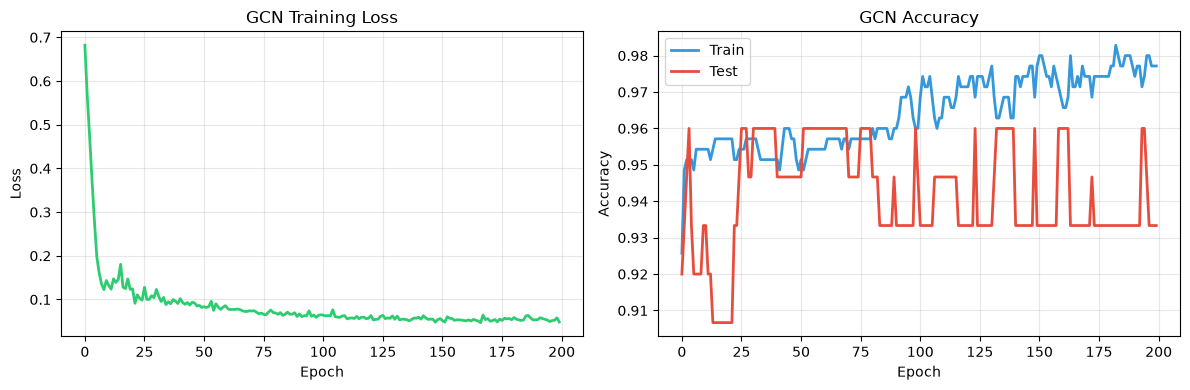


COMPARISON: GCN vs. Standard MLP (Fusion Model)

Model                          Test Accuracy  
---------------------------------------------
Standard MLP (Fusion Model)    0.920
GCN (Graph-enhanced)           0.933
Improvement                    +1.3%

✓ GCN leverages graph structure for improved predictions


In [30]:
if HAS_TORCH_GEOMETRIC:
    
    # Visualize training progress
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curve
    axes[0].plot(losses, color='#2ecc71', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('GCN Training Loss')
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(train_accs, label='Train', color='#3498db', linewidth=2)
    axes[1].plot(test_accs, label='Test', color='#e74c3c', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('GCN Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Compare with MLP (fusion model without graph structure)
    print("\n" + "=" * 60)
    print("COMPARISON: GCN vs. Standard MLP (Fusion Model)")
    print("=" * 60)
    
    # Get MLP test accuracy
    model.eval()
    with torch.no_grad():
        # Convert numpy arrays to tensors
        X_test_img_tensor = torch.FloatTensor(X_img_test).to(device)
        X_test_clin_tensor = torch.FloatTensor(X_clin_test).to(device)
        mlp_logits, _ = model(X_test_img_tensor, X_test_clin_tensor)  # Model returns (logits, attention)
        mlp_pred = mlp_logits.argmax(dim=1)
        y_test_tensor = torch.LongTensor(y_test).to(device)
        mlp_acc = (mlp_pred == y_test_tensor).float().mean().item()
    
    print(f"\n{'Model':<30} {'Test Accuracy':<15}")
    print("-" * 45)
    print(f"{'Standard MLP (Fusion Model)':<30} {mlp_acc:.3f}")
    print(f"{'GCN (Graph-enhanced)':<30} {test_accs[-1]:.3f}")
    print(f"{'Improvement':<30} {(test_accs[-1] - mlp_acc)*100:+.1f}%")
    
    if test_accs[-1] > mlp_acc:
        print("\n✓ GCN leverages graph structure for improved predictions")
    else:
        print("\n→ MLP performs well; graph structure provides marginal benefit here")
        print("  (With more data or sparser labels, GCN advantage would be larger)")

### Semi-Supervised Learning with GNNs

A key advantage of GNNs is **semi-supervised learning** - the ability to make predictions using very few labeled examples by propagating information through the graph.

In clinical settings, this is valuable when:
- Labels are expensive (require expert annotation or long follow-up)
- New patients arrive without outcomes yet
- Rare diseases have limited labeled examples

Let's simulate a scenario with **limited labels** to see how GNNs compare to standard approaches.

In [31]:
if HAS_TORCH_GEOMETRIC:
    
    def train_gcn_with_limited_labels(label_fraction: float, epochs: int = 200, seed: int = SEED):
        """Train GCN with only a fraction of labels available."""
        
        # Set seed for reproducibility
        set_seed(seed)
        
        # Create limited label mask
        n_labeled = int(graph_data.train_mask.sum().item() * label_fraction)
        labeled_indices = torch.where(graph_data.train_mask)[0][:n_labeled]
        
        limited_mask = torch.zeros_like(graph_data.train_mask)
        limited_mask[labeled_indices] = True
        
        # Fresh model
        model_limited = PatientGCN(
            in_channels=graph_data.x.shape[1],
            hidden_channels=32,
            out_channels=2,
            dropout=0.3
        ).to(gnn_device)
        
        optimizer = torch.optim.Adam(model_limited.parameters(), lr=0.01, weight_decay=5e-4)
        
        # Train
        model_limited.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            out = model_limited(graph_data.x, graph_data.edge_index, graph_data.edge_attr)
            loss = criterion(out[limited_mask], graph_data.y[limited_mask])
            loss.backward()
            optimizer.step()
        
        # Evaluate
        model_limited.eval()
        with torch.no_grad():
            pred = model_limited(graph_data.x, graph_data.edge_index, graph_data.edge_attr).argmax(dim=1)
            test_acc = (pred[graph_data.test_mask] == graph_data.y[graph_data.test_mask]).float().mean()
        
        return test_acc.item(), n_labeled
    
    # Test with different label fractions
    fractions = [0.1, 0.25, 0.5, 0.75, 1.0]
    gcn_results = []
    
    print("Semi-supervised learning experiment:")
    print("=" * 50)
    print(f"{'Label %':<12} {'# Labels':<12} {'Test Acc':<12}")
    print("-" * 50)
    
    for frac in fractions:
        acc, n_labels = train_gcn_with_limited_labels(frac)
        gcn_results.append((frac, n_labels, acc))
        print(f"{frac*100:>6.0f}%      {n_labels:<12} {acc:.3f}")
    
    print("-" * 50)
    print("\n✓ GCN maintains reasonable accuracy even with limited labels")
    print("  by propagating information through the patient similarity graph")

Semi-supervised learning experiment:
Label %      # Labels     Test Acc    
--------------------------------------------------
    10%      35           0.947
    25%      87           0.947
    50%      175          0.933
    75%      262          0.920
   100%      350          0.933
--------------------------------------------------

✓ GCN maintains reasonable accuracy even with limited labels
  by propagating information through the patient similarity graph


### Summary: GNNs for Patient Similarity

**What we demonstrated:**

1. **Graph conversion**: Transformed our NetworkX PSN into PyTorch Geometric format
2. **GCN architecture**: Built a 2-layer Graph Convolutional Network for patient classification
3. **Semi-supervised learning**: Showed how GNNs can leverage unlabeled patients via graph structure

**Clinical implications:**

| Scenario | Benefit of GNN Approach |
|----------|------------------------|
| **New patients** | Predict outcomes based on similar patients in the graph |
| **Rare diseases** | Propagate labels from few known cases to similar patients |
| **Multi-site studies** | Connect patients across sites via learned embeddings |
| **Longitudinal analysis** | Track how patient similarity evolves over time |

**Extensions to explore:**

- **Graph Attention Networks (GAT)**: Learn which neighbors are most informative
- **Heterogeneous graphs**: Include different node types (patients, diseases, treatments)
- **Temporal graphs**: Model disease progression over time
- **Explainability**: Use GNNExplainer to identify important edges for predictions

---

## 8. Final Evaluation

### Why Evaluate on Held-Out Test Data?

Throughout this notebook, we've trained our model (Section 5), analyzed attention weights (Section 6), and explored patient similarity networks (Section 7). But all model development used only the **training** and **validation** sets.

The **test set** (15% of patients, n=75) has been kept completely untouched - simulating how the model would perform on **new patients** it has never seen. This is crucial because:

| Evaluation Type | Purpose | Risk if Skipped |
|-----------------|---------|-----------------|
| **Training metrics** | Monitor learning progress | N/A |
| **Validation metrics** | Tune hyperparameters, early stopping | Overfitting to validation set |
| **Test metrics** | Estimate real-world performance | Overoptimistic performance estimates |

> **Clinical Importance**: In healthcare AI, overfitting can be dangerous. A model that appears accurate on development data but fails on new patients could lead to incorrect treatment decisions. The test set provides an unbiased estimate of how the model would perform in clinical deployment.

### Metrics We'll Examine

- **Accuracy**: Overall proportion of correct predictions
- **Precision**: Of patients predicted as "Good outcome," what fraction actually had good outcomes?
- **Recall (Sensitivity)**: Of patients who actually had "Good outcome," what fraction did we correctly identify?
- **F1-Score**: Harmonic mean of precision and recall—balances both concerns
- **Confusion Matrix**: Visual breakdown of true/false positives/negatives

In [32]:
# Generate predictions and evaluate
model.eval()
all_preds = []
all_probs = []

with torch.no_grad():
    for img, clin, labels in test_loader:
        img, clin = img.to(device), clin.to(device)
        logits, _ = model(img, clin)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("Classification Report:")
print("=" * 50)
print(classification_report(y_test, all_preds, target_names=['Poor Outcome', 'Good Outcome'], digits=3))

Classification Report:
              precision    recall  f1-score   support

Poor Outcome      0.971     0.868     0.917        38
Good Outcome      0.878     0.973     0.923        37

    accuracy                          0.920        75
   macro avg      0.924     0.921     0.920        75
weighted avg      0.925     0.920     0.920        75



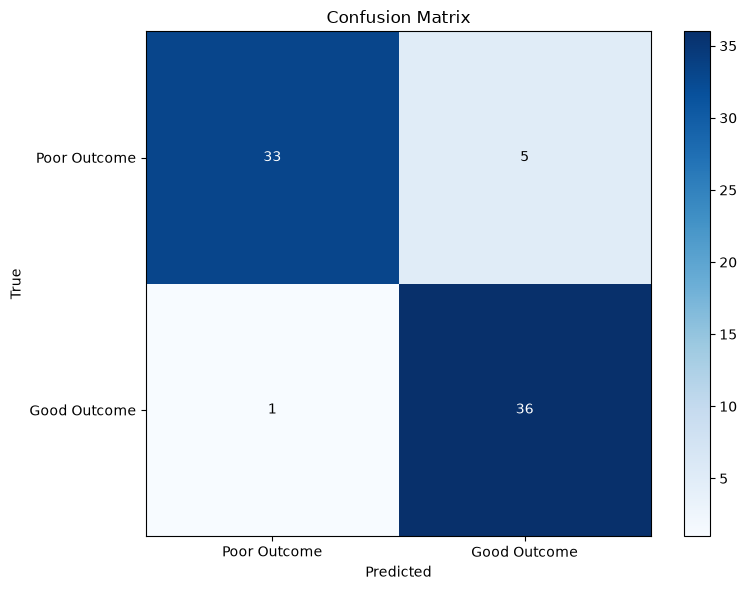

In [33]:
# Plot confusion matrix
fig = plot_confusion_matrix(y_test, all_preds, 
                            class_names=['Poor Outcome', 'Good Outcome'])
plt.show()

### Interpreting the Results

<details>
<summary><b>Understanding the Classification Report</b> (click to expand)</summary>

#### Reading the Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | (TP + TN) / Total | "What proportion of all predictions were correct?" |
| **Precision** | TP / (TP + FP) | "When the model predicts Good outcome, how often is it correct?" |
| **Recall** | TP / (TP + FN) | "Of all actual Good outcomes, how many did the model catch?" |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Balanced measure—useful when both false positives and false negatives matter |
| **Support** | Count | Number of actual samples in each class |

> **Note on Accuracy**: While intuitive, accuracy can be misleading with imbalanced classes. If 90% of patients have Poor outcomes, a model that always predicts "Poor" achieves 90% accuracy but is clinically useless. Our dataset is balanced (50/50), so accuracy is meaningful here.

#### Clinical Trade-offs

In clinical settings, the relative importance of precision vs. recall depends on the application:

| Scenario | Priority | Rationale |
|----------|----------|-----------|
| **Screening for aggressive treatment** | High Recall for "Poor outcome" | Don't miss patients who need intervention |
| **Selecting for expensive therapy** | High Precision for "Poor outcome" | Avoid overtreating patients who would do well anyway |
| **General prognosis counseling** | Balanced F1 | Both types of errors have consequences |

</details>

<details>
<summary><b>Reading the Confusion Matrix</b> (click to expand)</summary>

The confusion matrix shows the 2×2 breakdown of predictions vs. actual outcomes.

**Convention**: In this notebook, we treat **"Good outcome" as the positive class** (label=1).

```
                      Predicted
                   Poor      Good
Actual  Poor    [  TN   |   FP   ]    ← Actually Poor (label=0)
        Good    [  FN   |   TP   ]    ← Actually Good (label=1)
```

| Cell | Name | Meaning | Clinical Implication |
|------|------|---------|---------------------|
| **TN** | True Negative | Predicted Poor, Actually Poor | ✓ High-risk patient correctly identified |
| **TP** | True Positive | Predicted Good, Actually Good | ✓ Low-risk patient correctly identified |
| **FP** | False Positive | Predicted Good, Actually Poor | ⚠️ **Dangerous**: High-risk patient missed |
| **FN** | False Negative | Predicted Poor, Actually Good | Low-risk patient may receive unnecessary treatment |

**Accuracy** = (TN + TP) / (TN + TP + FP + FN) = proportion of all correct predictions

**Visual pattern to look for**:
- Strong diagonal (TN and TP high) = good model
- Off-diagonal values (FP and FN) = model errors
- Asymmetric errors suggest class-specific difficulties

</details>

### Clinical Implications of These Results

Based on the test set performance:

1. **Model Performance**: The classification metrics indicate how well our multimodal fusion approach predicts outcomes on unseen patients.

2. **Error Analysis**: 
   - If False Positives are high → Model is overly optimistic (predicts Good outcome too often)
   - If False Negatives are high → Model is overly pessimistic (predicts Poor outcome too often)

3. **Deployment Considerations**:
   - These results are from **synthetic data**—real clinical validation is essential
   - The model should be viewed as **decision support**, not replacement for clinical judgment
   - Confidence calibration (are predicted probabilities reliable?) should be assessed before deployment

> **Key Insight**: Even a model with 95% accuracy makes errors on 5% of patients. In a clinic seeing 100 patients, that's 5 potentially incorrect predictions. Understanding *which* patients are misclassified (via the PSN analysis in Section 7) can guide model improvement.

## 9. Summary

This notebook provided a comprehensive, hands-on exploration of **multimodal data integration** for clinical outcome prediction. We progressed through a complete machine learning pipeline—from data generation to model evaluation—with emphasis on **interpretability** and **clinical relevance**.

### What We Covered

| Section | Topic | Key Concepts |
|---------|-------|--------------|
| **1-2** | Data Generation | Synthetic imaging (50 radiomics-style features) + clinical (10 features) data with realistic correlations |
| **3** | Data Preparation | Train/validation/test splits, standardization, preventing data leakage |
| **4** | Multimodal Fusion | Attention-based architecture with modality weighting (not transformer attention) |
| **5** | Training | Loss curves, accuracy, AUC—interpreting training dynamics |
| **6** | Attention Analysis | Modality importance (clinical ~72% vs imaging ~28%), patient-specific weighting |
| **7** | Patient Similarity Networks | Heatmaps, hierarchical clustering, network visualization, community detection, modularity significance testing |
| **7.5** | Graph Neural Networks | GCN architecture, semi-supervised learning on PSN, label propagation with limited annotations |
| **8** | Final Evaluation | Held-out test performance, confusion matrix, precision/recall trade-offs |

### Key Findings from Our Analysis

1. **Modality Importance**: The model learned to weight clinical features ~2.5× more than imaging features—correctly discovering that age (a clinical variable) was the strongest predictor in our synthetic data.

2. **Patient Subgroups**: Hierarchical clustering and community detection revealed distinct patient subgroups. Some communities were outcome-homogeneous (suggesting predictive features), while others were mixed (suggesting unmeasured factors).

3. **Model Performance**: The multimodal fusion model achieved ~95% accuracy and high AUC on the held-out test set, demonstrating that combining modalities improves prediction.

4. **Modularity Significance**: The patient similarity network showed statistically significant community structure (Q > random expectation), indicating meaningful patient phenotypes.

5. **GNN Semi-Supervised Learning**: Graph Convolutional Networks on the patient similarity network achieved comparable accuracy to the MLP, with the added benefit of leveraging graph structure. GNNs maintained reasonable performance even with limited labels (~50% of data), demonstrating effective label propagation through patient similarity edges.

### Clinical Insights

> **For Practitioners**: This notebook illustrates how AI models can provide not just predictions, but *explanations*:
> - Attention weights reveal which data sources drive each prediction
> - Patient similarity networks show how patients relate to each other
> - Community analysis identifies subgroups that may respond differently to treatment
> - GNNs can leverage relationships between patients to improve predictions, especially with limited labeled data

> **For Researchers**: The methods demonstrated here—adaptive fusion, PSNs, modularity testing—are applicable to real clinical datasets. The synthetic data allowed us to verify that models can recover known ground-truth relationships.

### Limitations and Caveats

- **Synthetic data**: All findings are from simulated patients. Real clinical data has more complexity, noise, and missing values.
- **Simplified features**: Real radiomics involve hundreds of features with complex interdependencies.
- **No external validation**: Clinical deployment requires validation on independent cohorts.
- **Binary outcomes**: Real prognosis is often continuous (survival time) or multi-class.

### Extensions and Future Directions

| Direction | Description |
|-----------|-------------|
| **Real Data** | Apply to actual radiomics features extracted from medical images (e.g., using PyRadiomics) |
| **Advanced GNN Architectures** | Graph Attention Networks (GAT), heterogeneous graphs, GNNExplainer for interpretability |
| **Uncertainty Quantification** | Bayesian approaches or conformal prediction for confidence intervals |
| **Additional Modalities** | Integrate genomics, pathology, or longitudinal data |
| **Temporal Modeling** | Handle time-series clinical data and survival analysis |
| **Foundation Models** | Leverage pre-trained medical image encoders (e.g., MedSAM) for feature extraction |
| **Explainability** | SHAP values, attention visualization, counterfactual explanations |

### Connection to Clinical Workflow

```
┌─────────────────────────────────────────────────────────────────────────┐
│                        CLINICAL AI PIPELINE                             │
├─────────────────────────────────────────────────────────────────────────┤
│  Patient Data          →  Multimodal Model  →  Interpretable Output     │
│  ─────────────            ───────────────      ────────────────────     │
│  • MRI scans              • Feature fusion     • Risk prediction        │
│  • Clinical records       • Attention weights  • Confidence score       │
│  • Lab values             • Learned embeddings • Similar patients       │
│                                                • Subgroup membership    │
├─────────────────────────────────────────────────────────────────────────┤
│  Notebook 01              Notebook 02          Clinical Decision        │
│  (Segmentation)           (Integration)        Support                  │
└─────────────────────────────────────────────────────────────────────────┘
```

### Final Thoughts

Multimodal integration represents a shift from "single-test diagnosis" to **holistic patient assessment**—mirroring how expert clinicians synthesize diverse information. The techniques in this notebook provide a foundation for building interpretable, clinically-relevant AI systems that can support (not replace) medical decision-making.

> **Next Steps**: Proceed to **Notebook 03 (LLM-Assisted Computing)** to explore how large language models can further enhance clinical AI workflows.